In [1]:
#Installing all the required libraries
!pip install prophet

In [2]:
import prophet
print(prophet.__version__)

C:\Users\admin\anaconda3\envs\ds_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


1.4.0


In [3]:
from prophet import Prophet
print("Prophet imported successfully!")

Prophet imported successfully!


In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Prophet
from prophet import Prophet

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Additional utilities
import warnings

warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")

In [5]:
# data loading
df = pd.read_csv('agripulse_agricultural_produce.csv')
df.head(5)

,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,...,lag_1,lag_3,lag_6,lag_12,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label,commodity_type
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,...,NaN,NaN,NaN,NaN,160.000000,160.000000,160.000000,1.050687,Average,Legume
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,NaN,NaN,NaN,NaN,200.000000,200.000000,200.000000,1.097394,Average,Legume
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,200.0,NaN,NaN,NaN,200.000000,200.000000,200.000000,1.201201,Expensive,Legume
3,2024-09-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,200.0,NaN,NaN,NaN,196.666667,196.666667,196.666667,1.143326,Expensive,Legume
4,2023-12-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,NaN,NaN,NaN,NaN,155.000000,155.000000,155.000000,0.888363,Cheap,Legume


In [6]:
df.shape

(16347, 32)

In [7]:
df.columns.to_list()

['date',
 'region',
 'county',
 'market',
 'market_id',
 'latitude',
 'longitude',
 'category',
 'commodity',
 'commodity_id',
 'unit',
 'priceflag',
 'pricetype',
 'currency',
 'price',
 'usdprice',
 'date_month',
 'rainfall_mm',
 'price_per_kg',
 'month',
 'year',
 'season',
 'lag_1',
 'lag_3',
 'lag_6',
 'lag_12',
 'rolling_3m_avg',
 'rolling_6m_avg',
 'rolling_12m_avg',
 'price_vs_regional_avg',
 'price_label',
 'commodity_type']

In [8]:
#Dropping usdprice, priceflag, county
df = df.drop(columns=["usdprice", "priceflag", "county"])

In [9]:
# since we have two columns named price and price per kg, i want to see the similarity to decide if im keeping them
df[["price", "price_per_kg"]].head(20)

,price,price_per_kg
0,160.0,160.0
1,200.0,200.0
2,200.0,200.0
3,190.0,190.0
4,155.0,155.0
5,203.0,203.0
6,188.0,188.0
7,164.0,164.0
8,194.0,194.0
9,192.0,192.0


From the results, we can see that the values and the columns price and price per kg are similar. Therefore, I will drop the price column and keep the price_per_kg instead.

In [10]:
# dropping the price column
df = df.drop(columns=["price"])


In [11]:
# Making a copy of the df since we want to delete some columns
agri_df = df[df["commodity_type"].isin([
    "Cereal",
    "Legume",
    "Vegetable",
    "Tuber/Root Crop"
])].copy()

In [12]:
agri_df.columns.to_list()

['date',
 'region',
 'market',
 'market_id',
 'latitude',
 'longitude',
 'category',
 'commodity',
 'commodity_id',
 'unit',
 'pricetype',
 'currency',
 'date_month',
 'rainfall_mm',
 'price_per_kg',
 'month',
 'year',
 'season',
 'lag_1',
 'lag_3',
 'lag_6',
 'lag_12',
 'rolling_3m_avg',
 'rolling_6m_avg',
 'rolling_12m_avg',
 'price_vs_regional_avg',
 'price_label',
 'commodity_type']

In [13]:
# i will rename pricetype to price_type to match other columns naming convention
agri_df = agri_df.rename(columns={"pricetype": "price_type"})

In [14]:
# checking the missing dates and missing prices
agri_df["date"] = pd.to_datetime(agri_df["date"])

print(agri_df["date"].min())
print(agri_df["date"].max())
print(agri_df["date"].nunique())

print(agri_df["price_per_kg"].isna().sum())

2006-01-15 00:00:00
2026-08-15 00:00:00
248
0


In [15]:
agri_df.groupby(
    ["commodity", "region","market","price_type", "date"]
).size().value_counts().sort_index()

1    16347
Name: count, dtype: int64

In [16]:
duplicates = (
    agri_df.groupby(
        ["commodity", "region", "market","price_type", "date"]
    )
    .size()
    .reset_index(name="count")
)

duplicates[duplicates["count"] > 1]

,commodity,region,market,price_type,date,count


In [17]:
# Analyzing the sorghum market
agri_df[
    agri_df["commodity"].isin(
        ["Sorghum", "Sorghum (red)", "Sorghum (white)"]
    )
]["market"].value_counts()

market
Nairobi                            170
Kisumu                             161
Kitui                              145
Eldoret town (Uasin Gishu)         117
Nakuru                              62
Wakulima (Nakuru)                   41
Ethiopia (Kakuma)                   36
Hagadera (Daadab)                   34
Kakuma 3                            33
HongKong (Kakuma)                   31
Kakuma 4                            27
Mogadishu (Kakuma)                  26
Garissa town (Garissa)              21
Kalobeyei (Village 2)               20
Kakuma 2                            19
Kalobeyei (Village 3)               19
Kaanwa (Tharaka Nithi)              18
Karatina (Nyeri)                    17
IFO (Daadab)                        15
Marigat town (Baringo)              15
Dagahaley (Daadab)                  14
Kalobeyei (Village 1)               14
Kibuye (Kisumu)                     14
Kawangware (Nairobi)                12
Mathare (Nairobi)                   12
Kangemi (Nairobi) 

In [18]:
# excluding the refugee camp market since the prices may not be realistic due to subsidized commodities
refugee_markets = [
    "Ethiopia (Kakuma)",
    "Hagadera (Daadab)",
    "Kakuma 3",
    "HongKong (Kakuma)",
    "Kakuma 4",
    "Mogadishu (Kakuma)",
    "Kalobeyei (Village 2)",
    "Kakuma 2",
    "Kalobeyei (Village 3)",
    "IFO (Daadab)",
    "Dagahaley (Daadab)",
    "Kalobeyei (Village 1)"
]

In [19]:
# exclusing imported rice since we are working on locally produced commodities
excluded_commodities = [
    "Rice (imported, Pakistan)"
]

In [20]:
forecast_df = agri_df[
    ~agri_df["market"].isin(refugee_markets) &
    ~agri_df["commodity"].isin(excluded_commodities)
].copy()

In [21]:
# verifying the number of rows we removed
print("Original rows:", len(agri_df))
print("Forecasting rows:", len(forecast_df))
print("Rows removed:", len(agri_df) - len(forecast_df))

Original rows: 16347
Forecasting rows: 13416
Rows removed: 2931


## Preparing the Data for Price Forecasting

Before developing the forecasting models, the data needs to be structured as consistent time series. Because prices are reported at individual markets, the primary forecasting series will be defined by commodity, market, and price type, with date representing the time dimension.

An initial inspection showed that the same commodity, market, and date can have more than one observation when different price types are reported. For example, Nairobi recorded both retail and wholesale maize prices on 15 August 2020. These represent two different price series rather than duplicate observations.

Therefore, price_type will be retained as part of the forecasting series:

Commodity + Market + Price Type + Date

For example:

Maize + Nairobi + Retail
Maize + Nairobi + Wholesale

This prevents retail and wholesale prices from being mixed when calculating historical lags, rolling averages, or generating forecasts.

### Why Use Markets as the Primary Forecasting Unit?

Markets are the level at which the original price observations are recorded. Using markets as the primary geographic unit preserves local price variation that may otherwise be lost through regional aggregation.

This is particularly important when examining the relationship between rainfall and agricultural prices. Broad administrative regions can contain substantially different climatic and agricultural conditions. For example, rainfall patterns and agricultural conditions can vary considerably between different markets within the same region.

Therefore, region will be retained as geographical context rather than used as the primary forecasting unit. This allows the analysis to examine market-level price and rainfall relationships while still enabling comparisons across broader regions.

The resulting structure will be:

* **Commodity** — agricultural product being forecast
* **Market** — location where the price is observed
* **Price type** — retail or wholesale
* **Date** — monthly time index
* **Price per kg** — forecasting target
* **Rainfall** — climate predictor associated with the market location
* **Region** — broader geographical context

### Preparing the Data for Time-Series Analysis

Before creating lagged or rolling features, observations must be sorted chronologically within each forecasting series.

For each combination of commodity, market, and price type, the data should therefore follow a structure such as:

Maize + Nairobi + Retail

2020-01 → Price
2020-02 → Price
2020-03 → Price
2020-04 → Price
...

This ensures that a lag represents a previous time period within the same market and price type, rather than a different market or price series.

The same principle applies to rainfall. Rainfall features should be calculated within the appropriate market-level time series so that rainfall from one location does not incorrectly influence the price series of another location.

### Rainfall and Agricultural Price Relationships

One of the project's objectives is to evaluate whether rainfall variability provides useful information for predicting agricultural prices.

The relationship is expected to operate through agricultural production and market supply:

Rainfall variability → crop growth and harvesting → market supply → agricultural prices

However, rainfall may not affect prices immediately. Different commodities have different growing periods, maturity times, and harvesting cycles. Consequently, rainfall observed in previous months may contain more useful predictive information than rainfall observed in the same month.

For this reason, rainfall lag features will be evaluated during feature engineering. Potential variables include:

rainfall_lag_1 — rainfall from the previous month
rainfall_lag_2 — rainfall from two months earlier
rainfall_lag_3 — rainfall from three months earlier

The appropriate lag structure will not be assumed in advance. Its usefulness will be evaluated empirically for different commodities and forecasting models.

### Market-Level Forecasting and Regional Analysis

The primary forecasting analysis will therefore operate at the commodity-market-price-type level rather than aggregating all markets within a region into a single price series.

Regional aggregation can still be used for exploratory analysis and interpretation. For example, market-level results can later be compared across regions to determine whether rainfall-price relationships differ between geographic areas.

This approach preserves local variation while still allowing Agripulse to investigate broader agricultural and climate patterns across Kenya.

#### Step 1: Structure the Data by Forecasting Series

The first step is to sort the dataset by:

Commodity → Market → Price Type → Date

This establishes the correct chronological order for each forecasting series before missing periods, lagged variables, rolling statistics, and train-test splits are handled.

In [22]:
# checking the series
forecast_df = forecast_df.sort_values(
    ["commodity", "market", "price_type", "date"]
).reset_index(drop=True)

forecast_df["date_diff"] = (
    forecast_df.groupby(
        ["commodity", "market", "price_type"]
    )["date"].diff()
)

forecast_df["date_diff"].value_counts().head(15)

date_diff
31 days     5332
30 days     3106
28 days      747
92 days      701
91 days      444
61 days      444
29 days      149
62 days      146
59 days       92
365 days      72
181 days      69
90 days       68
122 days      66
183 days      61
184 days      57
Name: count, dtype: int64

In [23]:
series_counts = (
    forecast_df
    .groupby(["commodity", "market", "price_type"])
    .agg(
        observations=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .sort_values("observations")
)

series_counts.describe()

,observations,first_date,last_date
count,1324.000000,1324,1324
mean,10.132931,2022-11-07 23:14:19.214501,2024-04-09 15:22:17.764350
min,1.000000,2006-01-15 00:00:00,2012-03-15 00:00:00
25%,2.000000,2021-03-15 00:00:00,2023-06-15 00:00:00
50%,3.000000,2023-12-15 00:00:00,2024-09-15 00:00:00
75%,6.000000,2024-03-15 00:00:00,2025-09-15 00:00:00
max,189.000000,2026-04-15 00:00:00,2026-07-15 00:00:00
std,24.719264,NaN,NaN


In [24]:
series_counts.head(20)

observations first_date  \
commodity          market              price_type                            
Kale               Lolkunono           Retail                 1 2023-12-15   
Cowpeas (dry)      Bilbil              Retail                 1 2024-03-15   
Maize (white, dry) Masikita            Retail                 1 2024-09-15   
                   Matanomanne         Retail                 1 2026-03-15   
                   Mtito Andei         Retail                 1 2024-03-15   
Cowpeas            Makueni             Wholesale              1 2021-01-15   
                   Takaba (Mandera)    Wholesale              1 2023-04-15   
                   Wote town (Makueni) Wholesale              1 2021-01-15   
Maize (white, dry) Lorengipi           Retail                 1 2024-09-15   
                   Lororo Centre       Retail                 1 2025-03-15   
                   Kotile              Retail                 1 2026-03-15   
                   Liboi               Retail                 1 2024-06-15   
                   Lokiriama           Retail                 1 2023-12-15   
Cowpeas (dry)      Alungu              Retail                 1 2024-09-15   
                   Archers Post        Retail                 1 2026-03-15   
                   Banissa             Retail                 1 2025-06-15   
Kale               Kibish              Retail                 1 2025-09-15   
                   Kibwezi             Retail                 1 2024-03-15   
                   Kiliwaheri          Retail                 1 2023-12-15   
                   Kimalel Center      Retail                 1 2024-03-15   

                                                   last_date  
commodity          market              price_type             
Kale               Lolkunono           Retail     2023-12-15  
Cowpeas (dry)      Bilbil              Retail     2024-03-15  
Maize (white, dry) Masikita            Retail     2024-09-15  
                   Matanomanne         Retail     2026-03-15  
                   Mtito Andei         Retail     2024-03-15  
Cowpeas            Makueni             Wholesale  2021-01-15  
                   Takaba (Mandera)    Wholesale  2023-04-15  
                   Wote town (Makueni) Wholesale  2021-01-15  
Maize (white, dry) Lorengipi           Retail     2024-09-15  
                   Lororo Centre       Retail     2025-03-15  
                   Kotile              Retail     2026-03-15  
                   Liboi               Retail     2024-06-15  
                   Lokiriama           Retail     2023-12-15  
Cowpeas (dry)      Alungu              Retail     2024-09-15  
                   Archers Post        Retail     2026-03-15  
                   Banissa             Retail     2025-06-15  
Kale               Kibish              Retail     2025-09-15  
                   Kibwezi             Retail     2024-03-15  
                   Kiliwaheri          Retail     2023-12-15  
                   Kimalel Center      Retail     2024-03-15

In [25]:
# Count series by minimum number of observations
for threshold in [6, 12, 18, 24, 36, 48, 60]:
    n_series = (series_counts["observations"] >= threshold).sum()
    print(f"{threshold}+ observations: {n_series} series")

6+ observations: 381 series
12+ observations: 223 series
18+ observations: 172 series
24+ observations: 124 series
36+ observations: 64 series
48+ observations: 42 series
60+ observations: 42 series


In [26]:
# Distribution of series lengths
series_counts["observations"].value_counts().sort_index().head(30)

observations
1     303
2     196
3     168
4     157
5     119
6      76
7      42
8      10
9      20
10      4
11      6
12     21
13     12
14      3
15      3
16      8
17      4
18      6
19      4
20      9
21     14
22     12
23      3
24      3
25      4
26      3
27      6
28      6
29      5
30     15
Name: count, dtype: int64

In [27]:
# Keep only series with at least 24 observations
valid_series = series_counts[
    series_counts["observations"] >= 48
].index

forecast_model_df = forecast_df.set_index(
    ["commodity", "market", "price_type"]
).loc[valid_series].reset_index()

print("Original forecasting rows:", len(forecast_df))
print("Modeling rows:", len(forecast_model_df))
print("Number of series:", 
      forecast_model_df[
          ["commodity", "market", "price_type"]
      ].drop_duplicates().shape[0])

Original forecasting rows: 13416
Modeling rows: 5549
Number of series: 42


In [28]:
forecast_model_df.groupby(
    ["commodity", "market", "price_type"]
).size().describe()

count     42.000000
mean     132.119048
std       43.270112
min       62.000000
25%       79.500000
50%      144.500000
75%      167.000000
max      189.000000
dtype: float64

In [29]:
# Sort chronologically within each forecasting series
series_cols = ["commodity", "market", "price_type"]

forecast_model_df = forecast_model_df.sort_values(
    series_cols + ["date"]
).reset_index(drop=True)

# Rebuild lag features within each series
for lag in [1, 3, 6, 12]:
    forecast_model_df[f"lag_{lag}"] = (
        forecast_model_df
        .groupby(series_cols)["price_per_kg"]
        .shift(lag)
    )

# Rebuild rolling averages using ONLY previous observations
for window in [3, 6, 12]:
    forecast_model_df[f"rolling_{window}m_avg"] = (
        forecast_model_df
        .groupby(series_cols)["price_per_kg"]
        .transform(
            lambda x: x.shift(1).rolling(window).mean()
        )
    )

In [30]:
forecast_model_df[
    [
        "commodity",
        "market",
        "price_type",
        "date",
        "price_per_kg",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_3m_avg",
        "rolling_6m_avg",
        "rolling_12m_avg"
    ]
].head(15)

,commodity,market,price_type,date,price_per_kg,lag_1,lag_3,lag_6,lag_12,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg
0,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-01-15,45.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-02-15,44.02,45.85,NaN,NaN,NaN,NaN,NaN,NaN
2,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-03-15,50.54,44.02,NaN,NaN,NaN,NaN,NaN,NaN
3,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-04-15,48.60,50.54,45.85,NaN,NaN,46.803333,NaN,NaN
4,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-05-15,53.60,48.60,44.02,NaN,NaN,47.720000,NaN,NaN
5,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-06-15,46.06,53.60,50.54,NaN,NaN,50.913333,NaN,NaN
6,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-07-15,41.43,46.06,48.60,45.85,NaN,49.420000,48.111667,NaN
7,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-08-15,29.39,41.43,53.60,44.02,NaN,47.030000,47.375000,NaN
8,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-09-15,36.49,29.39,46.06,50.54,NaN,38.960000,44.936667,NaN
9,Beans,Eldoret town (Uasin Gishu),Wholesale,2006-10-15,38.18,36.49,41.43,48.60,NaN,35.770000,42.595000,NaN


In [31]:
forecast_model_df[
    [
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_3m_avg",
        "rolling_6m_avg",
        "rolling_12m_avg"
    ]
].isnull().sum()

lag_1               42
lag_3              126
lag_6              252
lag_12             504
rolling_3m_avg     126
rolling_6m_avg     252
rolling_12m_avg    504
dtype: int64

In [32]:
# Convert the date into a year-month period so we can check
# whether each forecasting series has more than one observation per month
forecast_model_df["year_month"] = (
    forecast_model_df["date"].dt.to_period("M")
)

# Count the number of observations for each
# commodity + market + price type + month combination
monthly_duplicates = (
    forecast_model_df
    .groupby(
        ["commodity", "market", "price_type", "year_month"]
    )
    .size()
)

# Show how many monthly combinations have 1, 2, 3, etc. observations
monthly_duplicates.value_counts().sort_index()

1    5549
Name: count, dtype: int64

In [33]:
# Check missing values in the key forecasting variables
forecast_model_df[
    ["price_per_kg", "rainfall_mm"]
].isnull().sum()

price_per_kg    0
rainfall_mm     0
dtype: int64

In [34]:
# Check the basic rainfall statistics
forecast_model_df["rainfall_mm"].describe()

count    5549.000000
mean      105.120753
std        84.830727
min         0.090000
25%        32.870000
50%        82.271250
75%       159.036000
max       428.300000
Name: rainfall_mm, dtype: float64

In [35]:
# Check the overall time period covered by the modeling dataset
print("Start date:", forecast_model_df["date"].min())
print("End date:", forecast_model_df["date"].max())

Start date: 2006-01-15 00:00:00
End date: 2022-04-15 00:00:00


In [36]:
# Show how many observations are available in each year
forecast_model_df["date"].dt.year.value_counts().sort_index()

date
2006    306
2007    312
2008    334
2009    344
2010    349
2011    345
2012    325
2013    334
2014    344
2015    442
2016    448
2017    474
2018    477
2019    440
2020    213
2021     52
2022     10
Name: count, dtype: int64

In [37]:
# Sort the data chronologically within each forecasting series
forecast_model_df = forecast_model_df.sort_values(
    ["commodity", "market", "price_type", "date"]
).reset_index(drop=True)

# Create an 80/20 time-based split within each forecasting series
def time_split(group):
    split_point = int(len(group) * 0.8)
    
    train = group.iloc[:split_point].copy()
    test = group.iloc[split_point:].copy()
    
    return train, test

# Apply the split separately to each commodity-market-price_type series
train_parts = []
test_parts = []

for _, group in forecast_model_df.groupby(
    ["commodity", "market", "price_type"]
):
    train, test = time_split(group)
    train_parts.append(train)
    test_parts.append(test)

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))
print("Total observations:", len(train_df) + len(test_df))

Training observations: 4425
Testing observations: 1124
Total observations: 5549


In [38]:
# Verify that the test set always comes after the training set
print("Latest training date:", train_df["date"].max())
print("Earliest testing date:", test_df["date"].min())

Latest training date: 2019-10-15 00:00:00
Earliest testing date: 2015-08-15 00:00:00


In [39]:
# Check that, within every forecasting series,
# all training observations occur before all testing observations
split_check = (
    train_df.groupby(["commodity", "market", "price_type"])["date"]
    .max()
    .to_frame("last_train_date")
    .join(
        test_df.groupby(["commodity", "market", "price_type"])["date"]
        .min()
        .to_frame("first_test_date")
    )
)

# Calculate the gap between the last training observation
# and the first testing observation for each series
split_check["date_gap"] = (
    split_check["first_test_date"] - split_check["last_train_date"]
)

print("Series checked:", len(split_check))
print("Invalid splits:", (split_check["date_gap"] <= pd.Timedelta(0)).sum())
print("Minimum gap:", split_check["date_gap"].min())

Series checked: 42
Invalid splits: 0
Minimum gap: 28 days 00:00:00


In [40]:
# Features that require historical price information
lag_features = [
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_3m_avg",
    "rolling_6m_avg",
    "rolling_12m_avg"
]

# Remove rows where the required historical features are unavailable
train_ml = train_df.dropna(subset=lag_features).copy()
test_ml = test_df.dropna(subset=lag_features).copy()

print("Training observations after lag preparation:", len(train_ml))
print("Testing observations after lag preparation:", len(test_ml))

Training observations after lag preparation: 3921
Testing observations after lag preparation: 1124


### Creating the Naive Baseline Model

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the previous month's price as the naïve forecast
test_baseline = test_df.dropna(subset=["lag_1"]).copy()

test_baseline["naive_prediction"] = test_baseline["lag_1"]

# Calculate baseline performance
naive_mae = mean_absolute_error(
    test_baseline["price_per_kg"],
    test_baseline["naive_prediction"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test_baseline["price_per_kg"],
        test_baseline["naive_prediction"]
    )
)

naive_mape = np.mean(
    np.abs(
        (test_baseline["price_per_kg"] - test_baseline["naive_prediction"])
        / test_baseline["price_per_kg"]
    )
) * 100

print(f"Naïve MAE:  {naive_mae:.4f}")
print(f"Naïve RMSE: {naive_rmse:.4f}")
print(f"Naïve MAPE: {naive_mape:.2f}%")

Naïve MAE:  4.2085
Naïve RMSE: 6.7087
Naïve MAPE: 8.12%


#### Sarima/Sarimax

In [42]:
maize_nairobi_wholesale = forecast_model_df[
    (forecast_model_df["commodity"] == "Maize") &
    (forecast_model_df["market"] == "Nairobi") &
    (forecast_model_df["price_type"] == "Wholesale")
].copy()

maize_nairobi_wholesale = maize_nairobi_wholesale.sort_values("date")

print("Observations:", len(maize_nairobi_wholesale))
print("Start date:", maize_nairobi_wholesale["date"].min())
print("End date:", maize_nairobi_wholesale["date"].max())

Observations: 189
Start date: 2006-01-15 00:00:00
End date: 2022-03-15 00:00:00


In [43]:
# Check for missing months
monthly_index = pd.date_range(
    start=maize_nairobi_wholesale["date"].min(),
    end=maize_nairobi_wholesale["date"].max(),
    freq="MS"
)

observed_months = maize_nairobi_wholesale["date"].dt.to_period("M")

missing_months = monthly_index.to_period("M").difference(observed_months)

print("Expected months:", len(monthly_index))
print("Observed months:", observed_months.nunique())
print("Missing months:", len(missing_months))

print("\nMissing months:")
print(missing_months)

Expected months: 194
Observed months: 189
Missing months: 6

Missing months:
PeriodIndex(['2018-04', '2020-05', '2020-06', '2020-12', '2021-12', '2022-01'], dtype='period[M]')


In [44]:
# Create a proper monthly date column
maize_nairobi_wholesale["month_date"] = (
    maize_nairobi_wholesale["date"].dt.to_period("M").dt.to_timestamp()
)

# Create the monthly time series
maize_ts = (
    maize_nairobi_wholesale
    .set_index("month_date")["price_per_kg"]
    .asfreq("MS")
)

print("Total months:", len(maize_ts))
print("Missing prices:", maize_ts.isna().sum())

print("\nMissing dates:")
print(maize_ts[maize_ts.isna()])

Total months: 195
Missing prices: 6

Missing dates:
month_date
2018-04-01   NaN
2020-05-01   NaN
2020-06-01   NaN
2020-12-01   NaN
2021-12-01   NaN
2022-01-01   NaN
Name: price_per_kg, dtype: float64


In [45]:
# split into train and test
# Chronological 80/20 train-test split
split_point = int(len(maize_ts) * 0.8)

train_maize = maize_ts.iloc[:split_point]
test_maize = maize_ts.iloc[split_point:]

print("Training observations:", len(train_maize))
print("Testing observations:", len(test_maize))

print("\nTraining period:")
print(train_maize.index.min(), "to", train_maize.index.max())

print("\nTesting period:")
print(test_maize.index.min(), "to", test_maize.index.max())

print("\nMissing values in training:", train_maize.isna().sum())
print("Missing values in testing:", test_maize.isna().sum())

Training observations: 156
Testing observations: 39

Training period:
2006-01-01 00:00:00 to 2018-12-01 00:00:00

Testing period:
2019-01-01 00:00:00 to 2022-03-01 00:00:00

Missing values in training: 1
Missing values in testing: 5


In [46]:
from statsmodels.tsa.stattools import adfuller

# Remove missing observations for the ADF test
train_maize_adf = train_maize.dropna()

adf_result = adfuller(train_maize_adf)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.2050610798512214
p-value: 0.20441370758955146

Critical Values:
1%: -3.474120870218417
5%: -2.880749791423677
10%: -2.5770126333102494


In [47]:
# First difference the training series
train_maize_diff = train_maize.dropna().diff().dropna()

# ADF test on the differenced series
adf_diff_result = adfuller(train_maize_diff)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])

print("\nCritical Values:")
for key, value in adf_diff_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -9.089326557955308
p-value: 3.862481054173343e-15

Critical Values:
1%: -3.474120870218417
5%: -2.880749791423677
10%: -2.5770126333102494


The original series is non-stationary, but becomes stationary after first differencing. Therefore, d = 1.

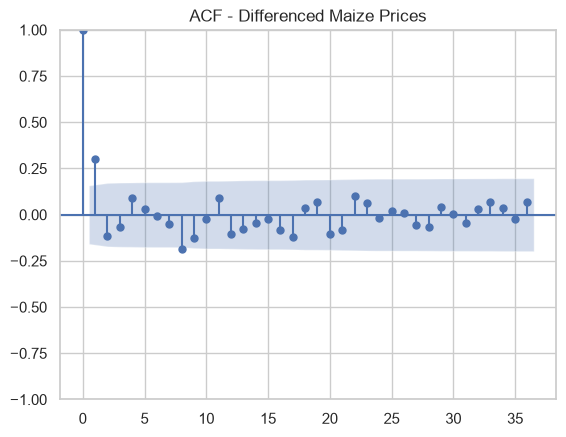

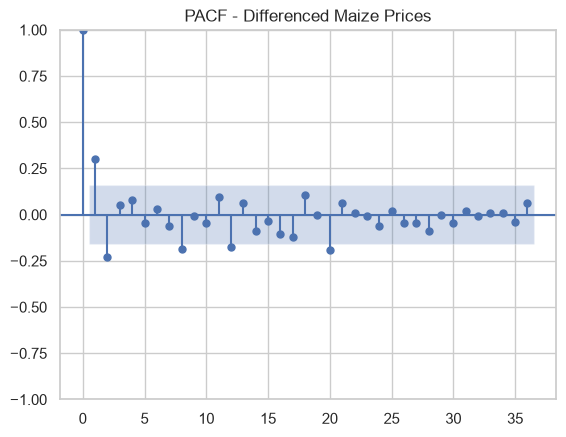

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Use the stationary differenced training series
train_maize_diff = train_maize.dropna().diff().dropna()

# ACF
plot_acf(train_maize_diff, lags=36)
plt.title("ACF - Differenced Maize Prices")
plt.show()

# PACF
plot_pacf(train_maize_diff, lags=36, method="ywm")
plt.title("PACF - Differenced Maize Prices")
plt.show()

In [49]:
from statsmodels.tsa.stattools import acf, pacf

# Stationary differenced training series
train_maize_diff = train_maize.dropna().diff().dropna()

# Calculate ACF and PACF
acf_values = acf(train_maize_diff, nlags=36)
pacf_values = pacf(train_maize_diff, nlags=36, method="ywm")

# Print values
print("Lag    ACF        PACF")
print("-" * 25)

for lag in range(1, 37):
    print(f"{lag:2d}   {acf_values[lag]:8.4f}   {pacf_values[lag]:8.4f}")

Lag    ACF        PACF
-------------------------
 1     0.3006     0.3006
 2    -0.1161    -0.2270
 3    -0.0650     0.0533
 4     0.0878     0.0789
 5     0.0294    -0.0462
 6    -0.0083     0.0308
 7    -0.0512    -0.0607
 8    -0.1879    -0.1885
 9    -0.1258    -0.0076
10    -0.0248    -0.0441
11     0.0903     0.0948
12    -0.1058    -0.1743
13    -0.0780     0.0640
14    -0.0453    -0.0870
15    -0.0226    -0.0353
16    -0.0821    -0.1023
17    -0.1214    -0.1220
18     0.0376     0.1070
19     0.0664    -0.0030
20    -0.1071    -0.1928
21    -0.0832     0.0625
22     0.0991     0.0101
23     0.0647    -0.0089
24    -0.0154    -0.0608
25     0.0194     0.0177
26     0.0115    -0.0429
27    -0.0534    -0.0467
28    -0.0682    -0.0887
29     0.0388    -0.0042
30     0.0043    -0.0439
31    -0.0463     0.0201
32     0.0308    -0.0056
33     0.0689     0.0067
34     0.0366     0.0110
35    -0.0249    -0.0414
36     0.0678     0.0639


In [50]:
import numpy as np

n = len(train_maize_diff)

confidence = 1.96 / np.sqrt(n)

print("95% significance threshold:", round(confidence, 4))

print("\nSignificant ACF lags:")
for lag in range(1, 37):
    if abs(acf_values[lag]) > confidence:
        print(lag, round(acf_values[lag], 4))

print("\nSignificant PACF lags:")
for lag in range(1, 37):
    if abs(pacf_values[lag]) > confidence:
        print(lag, round(pacf_values[lag], 4))

95% significance threshold: 0.1579

Significant ACF lags:
1 0.3006
8 -0.1879

Significant PACF lags:
1 0.3006
2 -0.227
8 -0.1885
12 -0.1743
20 -0.1928


In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Candidate SARIMA models
sarima_candidates = {
    "SARIMA_1": ((1, 1, 1), (0, 0, 0, 12)),
    "SARIMA_2": ((2, 1, 1), (0, 0, 0, 12)),
    "SARIMA_3": ((1, 1, 1), (1, 0, 0, 12)),
    "SARIMA_4": ((2, 1, 1), (1, 0, 0, 12)),
    "SARIMA_5": ((1, 1, 0), (0, 0, 1, 12)),
    "SARIMA_6": ((2, 1, 0), (0, 0, 1, 12))
}

results = []

for name, (order, seasonal_order) in sarima_candidates.items():

    print(f"\nFitting {name}: order={order}, seasonal_order={seasonal_order}")

    model = SARIMAX(
        train_maize,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    results.append({
        "Model": name,
        "Order": order,
        "Seasonal_Order": seasonal_order,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })

sarima_results = pd.DataFrame(results)

print("\nSARIMA Model Comparison:")
print(sarima_results.sort_values("AIC"))


Fitting SARIMA_1: order=(1, 1, 1), seasonal_order=(0, 0, 0, 12)

Fitting SARIMA_2: order=(2, 1, 1), seasonal_order=(0, 0, 0, 12)

Fitting SARIMA_3: order=(1, 1, 1), seasonal_order=(1, 0, 0, 12)

Fitting SARIMA_4: order=(2, 1, 1), seasonal_order=(1, 0, 0, 12)

Fitting SARIMA_5: order=(1, 1, 0), seasonal_order=(0, 0, 1, 12)

Fitting SARIMA_6: order=(2, 1, 0), seasonal_order=(0, 0, 1, 12)

SARIMA Model Comparison:
      Model      Order Seasonal_Order         AIC         BIC
3  SARIMA_4  (2, 1, 1)  (1, 0, 0, 12)  671.044807  685.788606
5  SARIMA_6  (2, 1, 0)  (0, 0, 1, 12)  672.566381  684.389690
2  SARIMA_3  (1, 1, 1)  (1, 0, 0, 12)  675.499845  687.323153
4  SARIMA_5  (1, 1, 0)  (0, 0, 1, 12)  679.323087  688.190568
1  SARIMA_2  (2, 1, 1)  (0, 0, 0, 12)  718.419353  730.541104
0  SARIMA_1  (1, 1, 1)  (0, 0, 0, 12)  718.670376  727.761689


In [52]:
# Fit the best AIC model
sarima4_model = SARIMAX(
    train_maize,
    order=(2, 1, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima4_fitted = sarima4_model.fit(disp=False)

# Forecast the test period
sarima4_forecast = sarima4_fitted.forecast(steps=len(test_maize))

print(sarima4_forecast.head(10))

2019-01-01    24.237515
2019-02-01    24.628010
2019-03-01    25.023819
2019-04-01    25.134378
2019-05-01    25.125415
2019-06-01    25.140288
2019-07-01    25.414609
2019-08-01    25.675986
2019-09-01    25.893047
2019-10-01    26.378098
Freq: MS, Name: predicted_mean, dtype: float64


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Align actual and predicted values
comparison = pd.DataFrame({
    "Actual": test_maize,
    "Predicted": sarima4_forecast
}).dropna()

# Calculate metrics
mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Predicted"]
    )
)

mape = np.mean(
    np.abs(
        (comparison["Actual"] - comparison["Predicted"])
        / comparison["Actual"]
    )
) * 100

print("SARIMA_4 Performance")
print("---------------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("MAPE:", round(mape, 2), "%")

SARIMA_4 Performance
---------------------
MAE : 8.2907
RMSE: 9.1975
MAPE: 23.27 %


In [54]:
print("\nActual vs Predicted - First 10 observations")
print(comparison.head(10))


Actual vs Predicted - First 10 observations
            Actual  Predicted
2019-01-01   27.11  24.237515
2019-02-01   27.08  24.628010
2019-03-01   26.13  25.023819
2019-04-01   31.30  25.134378
2019-05-01   34.74  25.125415
2019-06-01   26.85  25.140288
2019-07-01   45.29  25.414609
2019-08-01   37.71  25.675986
2019-09-01   36.45  25.893047
2019-10-01   41.26  26.378098


In [55]:
# Fit SARIMA_6
sarima6_model = SARIMAX(
    train_maize,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima6_fitted = sarima6_model.fit(disp=False)

# Forecast the test period
sarima6_forecast = sarima6_fitted.forecast(
    steps=len(test_maize)
)

print(sarima6_forecast.head(10))

2019-01-01    24.313440
2019-02-01    24.627603
2019-03-01    24.955381
2019-04-01    25.059036
2019-05-01    24.974007
2019-06-01    24.874041
2019-07-01    25.216332
2019-08-01    25.661845
2019-09-01    25.960129
2019-10-01    26.579188
Freq: MS, Name: predicted_mean, dtype: float64


In [56]:
# Align actual and predicted values
comparison6 = pd.DataFrame({
    "Actual": test_maize,
    "Predicted": sarima6_forecast
}).dropna()

# Metrics
mae6 = mean_absolute_error(
    comparison6["Actual"],
    comparison6["Predicted"]
)

rmse6 = np.sqrt(
    mean_squared_error(
        comparison6["Actual"],
        comparison6["Predicted"]
    )
)

mape6 = np.mean(
    np.abs(
        (comparison6["Actual"] - comparison6["Predicted"])
        / comparison6["Actual"]
    )
) * 100

print("SARIMA_6 Performance")
print("---------------------")
print("MAE :", round(mae6, 4))
print("RMSE:", round(rmse6, 4))
print("MAPE:", round(mape6, 2), "%")

SARIMA_6 Performance
---------------------
MAE : 8.117
RMSE: 9.0304
MAPE: 22.78 %


In [57]:
print("\nActual vs Predicted - First 10 observations")
print(comparison6.head(10))


Actual vs Predicted - First 10 observations
            Actual  Predicted
2019-01-01   27.11  24.313440
2019-02-01   27.08  24.627603
2019-03-01   26.13  24.955381
2019-04-01   31.30  25.059036
2019-05-01   34.74  24.974007
2019-06-01   26.85  24.874041
2019-07-01   45.29  25.216332
2019-08-01   37.71  25.661845
2019-09-01   36.45  25.960129
2019-10-01   41.26  26.579188


### SARIMA Model Evaluation – Key Observation

The SARIMA models were evaluated against the naïve baseline using MAE, RMSE, and MAPE. SARIMA_6, with specification `(2,1,0)(0,0,1,12)`, produced the best SARIMA performance, with an MAE of 8.12, RMSE of 9.03, and MAPE of 22.78%.

However, the naïve baseline performed better on MAE (6.35) and MAPE (11.59%), while SARIMA_6 achieved a lower RMSE (9.03) compared with the naïve model (11.76%). This suggests that SARIMA reduced the impact of some larger forecasting errors but was less accurate on typical price predictions.

The SARIMA forecasts also tended to underestimate substantial price increases, indicating that historical price patterns and seasonality alone may not capture all the factors influencing maize prices.

Therefore, SARIMA_6 will be retained as the best SARIMA candidate, but the results indicate that incorporating relevant external variables may improve forecasting performance. The analysis will next evaluate SARIMAX to determine whether exogenous factors such as rainfall and economic variables provide additional predictive information.

### Testing if adding variables such as Rainfall to Sarima(Sarimax) will improve price forecasting beyond historical prices

In [58]:
print(forecast_model_df.columns.tolist())

['commodity', 'market', 'price_type', 'date', 'region', 'market_id', 'latitude', 'longitude', 'category', 'commodity_id', 'unit', 'currency', 'date_month', 'rainfall_mm', 'price_per_kg', 'month', 'year', 'season', 'lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_3m_avg', 'rolling_6m_avg', 'rolling_12m_avg', 'price_vs_regional_avg', 'price_label', 'commodity_type', 'date_diff', 'year_month']


In [59]:
# Select the maize Nairobi wholesale series
maize_nairobi_sarimax = forecast_model_df[
    (forecast_model_df["commodity"] == "Maize") &
    (forecast_model_df["market"] == "Nairobi") &
    (forecast_model_df["price_type"] == "Wholesale")
].copy()

# Sort chronologically
maize_nairobi_sarimax = maize_nairobi_sarimax.sort_values("date")

# Create monthly date
maize_nairobi_sarimax["month_date"] = (
    maize_nairobi_sarimax["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Create rainfall lags
for lag in [1, 3, 6]:
    maize_nairobi_sarimax[f"rainfall_lag_{lag}"] = (
        maize_nairobi_sarimax["rainfall_mm"].shift(lag)
    )

print(
    maize_nairobi_sarimax[
        [
            "month_date",
            "price_per_kg",
            "rainfall_mm",
            "rainfall_lag_1",
            "rainfall_lag_3",
            "rainfall_lag_6"
        ]
    ].head(15)
)

     month_date  price_per_kg  rainfall_mm  rainfall_lag_1  rainfall_lag_3  \
2297 2006-01-01         15.48        17.97             NaN             NaN   
2298 2006-02-01         16.41        20.13           17.97             NaN   
2299 2006-03-01         16.91        88.87           20.13             NaN   
2300 2006-04-01         17.02       153.59           88.87           17.97   
2301 2006-05-01         17.71        93.38          153.59           20.13   
2302 2006-06-01         16.96        12.31           93.38           88.87   
2303 2006-07-01         18.61        16.16           12.31          153.59   
2304 2006-08-01         17.50        52.57           16.16           93.38   
2305 2006-09-01         14.80        17.32           52.57           12.31   
2306 2006-10-01         14.34        49.60           17.32           16.16   
2307 2006-11-01         14.19       165.37           49.60           52.57   
2308 2006-12-01         13.34       127.12          165.37      

In [60]:
print("\nCorrelation with price:")
print(
    maize_nairobi_sarimax[
        [
            "price_per_kg",
            "rainfall_mm",
            "rainfall_lag_1",
            "rainfall_lag_3",
            "rainfall_lag_6"
        ]
    ].corr()["price_per_kg"].sort_values(ascending=False)
)


Correlation with price:
price_per_kg      1.000000
rainfall_lag_1    0.093204
rainfall_mm       0.057388
rainfall_lag_3    0.046027
rainfall_lag_6    0.000978
Name: price_per_kg, dtype: float64


In [61]:
maize_rainfall = (
    maize_nairobi_sarimax[
        ["month_date", "rainfall_mm"]
    ]
    .drop_duplicates("month_date")
    .set_index("month_date")
    .asfreq("MS")
)

# Create exact calendar-month rainfall lags
for lag in [1, 3, 6]:
    maize_rainfall[f"rainfall_lag_{lag}"] = (
        maize_rainfall["rainfall_mm"].shift(lag)
    )

maize_rainfall.head(15)

,rainfall_mm,rainfall_lag_1,rainfall_lag_3,rainfall_lag_6
month_date,,,,
2006-01-01,17.97,NaN,NaN,NaN
2006-02-01,20.13,17.97,NaN,NaN
2006-03-01,88.87,20.13,NaN,NaN
2006-04-01,153.59,88.87,17.97,NaN
2006-05-01,93.38,153.59,20.13,NaN
2006-06-01,12.31,93.38,88.87,NaN
2006-07-01,16.16,12.31,153.59,17.97
2006-08-01,52.57,16.16,93.38,20.13
2006-09-01,17.32,52.57,12.31,88.87


In [62]:
maize_rainfall.isna().sum()

rainfall_mm        6
rainfall_lag_1     7
rainfall_lag_3     8
rainfall_lag_6    10
dtype: int64

In [63]:
# creating a sarimax modeling data
# Combine maize prices with one-month lagged rainfall
maize_sarimax = (
    maize_ts.to_frame("price_per_kg")
    .join(
        maize_rainfall[["rainfall_lag_1"]],
        how="left"
    )
)

# Remove rows where lagged rainfall is unavailable
maize_sarimax = maize_sarimax.dropna()

# Check the resulting data
print(maize_sarimax.head())
print("\nShape:", maize_sarimax.shape)
print("\nMissing values:")
print(maize_sarimax.isna().sum())

            price_per_kg  rainfall_lag_1
month_date                              
2006-02-01         16.41           17.97
2006-03-01         16.91           20.13
2006-04-01         17.02           88.87
2006-05-01         17.71          153.59
2006-06-01         16.96           93.38

Shape: (184, 2)

Missing values:
price_per_kg      0
rainfall_lag_1    0
dtype: int64


### Sarimax Train/Test split

In [64]:
# Chronological 80/20 split
split_point = int(len(maize_sarimax) * 0.8)

train_sarimax = maize_sarimax.iloc[:split_point]
test_sarimax = maize_sarimax.iloc[split_point:]

# Endogenous variable: maize price
y_train = train_sarimax["price_per_kg"]
y_test = test_sarimax["price_per_kg"]

# Exogenous variable: lagged rainfall
X_train = train_sarimax[["rainfall_lag_1"]]
X_test = test_sarimax[["rainfall_lag_1"]]

print("Training observations:", len(train_sarimax))
print("Testing observations:", len(test_sarimax))

print("\nTraining period:")
print(y_train.index.min(), "to", y_train.index.max())

print("\nTesting period:")
print(y_test.index.min(), "to", y_test.index.max())

Training observations: 147
Testing observations: 37

Training period:
2006-02-01 00:00:00 to 2018-06-01 00:00:00

Testing period:
2018-07-01 00:00:00 to 2022-03-01 00:00:00


In [65]:
# fitting Sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

print(sarimax_result.summary())

C:\Users\admin\anaconda3\envs\ds_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\envs\ds_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                         price_per_kg   No. Observations:                  147
Model:             SARIMAX(2, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -312.807
Date:                              Thu, 10 Sep 2026   AIC                            635.615
Time:                                      06:57:36   BIC                            650.066
Sample:                                           0   HQIC                           641.487
                                              - 147                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
rainfall_lag_1     0.0023      0.004      0.527      0.598      -0.006       0.011
ar.L1  

In [66]:
print(type(y_train.index))
print(y_train.index)
print("\nFrequency:", y_train.index.freq)

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2006-02-01', '2006-03-01', '2006-04-01', '2006-05-01',
               '2006-06-01', '2006-07-01', '2006-08-01', '2006-09-01',
               '2006-10-01', '2006-11-01',
               ...
               '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01',
               '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01',
               '2018-03-01', '2018-06-01'],
              dtype='datetime64[us]', name='month_date', length=147, freq=None)

Frequency: None


In [67]:
# Give the training series an explicit monthly frequency
y_train_sarimax = y_train.asfreq("MS")

X_train_sarimax = X_train.reindex(y_train_sarimax.index)

print("Training observations:", len(y_train_sarimax))
print("Missing prices:", y_train_sarimax.isna().sum())
print("Missing rainfall:", X_train_sarimax.isna().sum())
print("Frequency:", y_train_sarimax.index.freq)

Training observations: 149
Missing prices: 2
Missing rainfall: rainfall_lag_1    2
dtype: int64
Frequency: <MonthBegin>


In [68]:
# Keep only months where both price and rainfall lag are available
sarimax_train = pd.concat(
    [y_train_sarimax, X_train_sarimax],
    axis=1
).dropna()

y_train_final = sarimax_train["price_per_kg"]
X_train_final = sarimax_train[["rainfall_lag_1"]]

print("Training observations:", len(y_train_final))
print("Missing values:")
print(sarimax_train.isna().sum())

print("\nTraining period:")
print(y_train_final.index.min(), "to", y_train_final.index.max())

print("\nFrequency:", y_train_final.index.freq)

Training observations: 147
Missing values:
price_per_kg      0
rainfall_lag_1    0
dtype: int64

Training period:
2006-02-01 00:00:00 to 2018-06-01 00:00:00

Frequency: None


In [82]:
# Reset the index for SARIMAX modeling
y_train_model = y_train_final.reset_index(drop=True)
X_train_model = X_train_final.reset_index(drop=True)

print("y_train_model:", len(y_train_model))
print("X_train_model:", len(X_train_model))

print("\nMissing values:")
print("y_train_model:", y_train_model.isna().sum())
print("X_train_model:", X_train_model.isna().sum())

y_train_model: 147
X_train_model: 147

Missing values:
y_train_model: 0
X_train_model: rainfall_lag_1    0
dtype: int64


In [75]:
print("y_test:", len(y_test))
print("X_test:", len(X_test))
print("test_sarimax:", len(test_sarimax))

print("\ny_test index:")
print(y_test.index[[0, -1]])

print("\nX_test index:")
print(X_test.index[[0, -1]])

y_test: 37
X_test: 37
test_sarimax: 37

y_test index:
DatetimeIndex(['2018-07-01', '2022-03-01'], dtype='datetime64[us]', name='month_date', freq=None)

X_test index:
DatetimeIndex(['2018-07-01', '2022-03-01'], dtype='datetime64[us]', name='month_date', freq=None)


In [77]:
#fitting the sarimax model
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    y_train_model,
    exog=X_train_model,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

print(sarimax_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         price_per_kg   No. Observations:                  147
Model:             SARIMAX(2, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -312.807
Date:                              Thu, 10 Sep 2026   AIC                            635.615
Time:                                      07:09:08   BIC                            650.066
Sample:                                           0   HQIC                           641.487
                                              - 147                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
rainfall_lag_1     0.0023      0.004      0.527      0.598      -0.006       0.011
ar.L1  

In [84]:
# Prepare the test data for SARIMAX

# Give the test series an explicit monthly frequency
y_test_sarimax = y_test.asfreq("MS")

# Align rainfall data with the test period
X_test_sarimax = X_test.reindex(y_test_sarimax.index)

# Keep only months where both price and rainfall lag are available
sarimax_test = pd.concat(
    [y_test_sarimax, X_test_sarimax],
    axis=1
).dropna()

# Separate target and exogenous variable
y_test_final = sarimax_test["price_per_kg"]
X_test_final = sarimax_test[["rainfall_lag_1"]]

print("Test observations:", len(y_test_final))
print("Missing values:")
print(sarimax_test.isna().sum())

print("\nTest period:")
print(y_test_final.index.min(), "to", y_test_final.index.max())

Test observations: 37
Missing values:
price_per_kg      0
rainfall_lag_1    0
dtype: int64

Test period:
2018-07-01 00:00:00 to 2022-03-01 00:00:00


In [85]:
# Reset indexes for SARIMAX prediction
y_test_model = y_test_final.reset_index(drop=True)
X_test_model = X_test_final.reset_index(drop=True)

print("y_test_model:", len(y_test_model))
print("X_test_model:", len(X_test_model))

y_test_model: 37
X_test_model: 37


In [86]:
# Generate SARIMAX predictions
sarimax_prediction = sarimax_result.get_forecast(
    steps=len(X_test_model),
    exog=X_test_model
)

sarimax_pred = sarimax_prediction.predicted_mean

# Restore the actual test dates
sarimax_pred.index = y_test_final.index

print("First 10 SARIMAX predictions:")
print(sarimax_pred.head(10))

First 10 SARIMAX predictions:
month_date
2018-07-01    31.824473
2018-08-01    30.654409
2018-09-01    31.054952
2018-10-01    32.828968
2018-11-01    33.562253
2018-12-01    34.525605
2019-01-01    34.122725
2019-02-01    33.905496
2019-03-01    33.496947
2019-04-01    34.270051
Name: predicted_mean, dtype: float64


In [87]:
# Evaluating Sarimax predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
sarimax_mae = mean_absolute_error(
    y_test_final,
    sarimax_pred
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        sarimax_pred
    )
)

sarimax_mape = np.mean(
    np.abs(
        (y_test_final - sarimax_pred) / y_test_final
    )
) * 100

print("SARIMAX Performance")
print("-------------------")
print(f"MAE:  {sarimax_mae:.4f}")
print(f"RMSE: {sarimax_rmse:.4f}")
print(f"MAPE: {sarimax_mape:.2f}%")

SARIMAX Performance
-------------------
MAE:  3.7631
RMSE: 4.9696
MAPE: 12.94%


In [88]:
sarimax_comparison = pd.DataFrame({
    "actual": y_test_final,
    "predicted": sarimax_pred
})

print(sarimax_comparison.head(10))

            actual  predicted
month_date                   
2018-07-01   30.19  31.824473
2018-08-01   28.00  30.654409
2018-09-01   26.20  31.054952
2018-10-01   22.17  32.828968
2018-11-01   23.43  33.562253
2018-12-01   24.46  34.525605
2019-01-01   27.11  34.122725
2019-02-01   27.08  33.905496
2019-03-01   26.13  33.496947
2019-04-01   31.30  34.270051


Adding rainfall lag 1 substantially improved out-of-sample forecasting performance, even though the individual rainfall coefficient was not statistically significant.

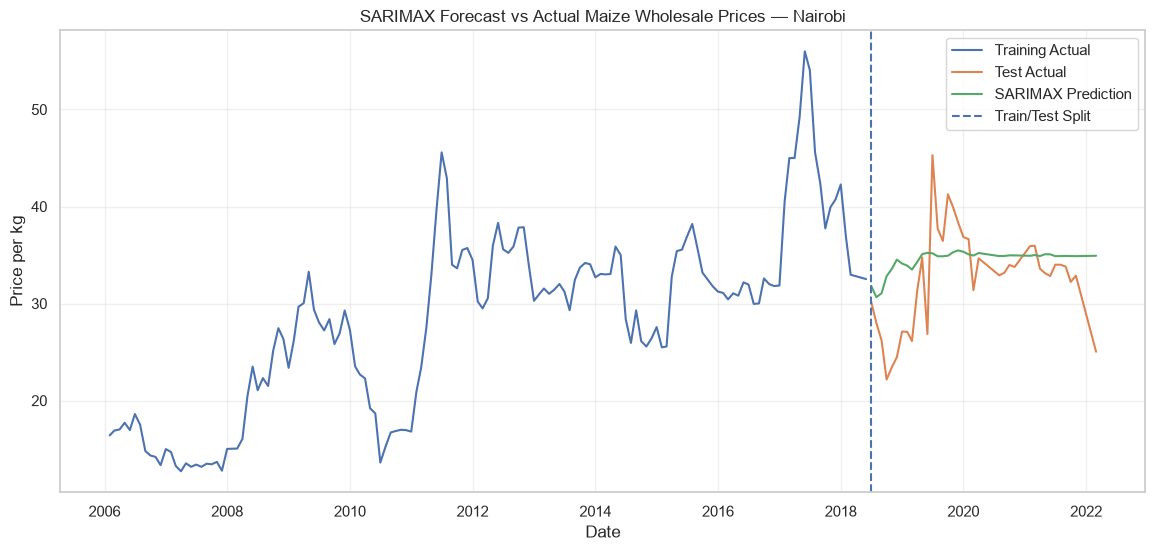

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(
    y_train_final.index,
    y_train_final,
    label="Training Actual"
)

# Plot test actual prices
plt.plot(
    y_test_final.index,
    y_test_final,
    label="Test Actual"
)

# Plot SARIMAX predictions
plt.plot(
    sarimax_pred.index,
    sarimax_pred,
    label="SARIMAX Prediction"
)

# Mark train/test boundary
plt.axvline(
    x=y_test_final.index[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("SARIMAX Forecast vs Actual Maize Wholesale Prices — Nairobi")
plt.xlabel("Date")
plt.ylabel("Price per kg")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### Testing Sarimax with rainfall lag 3

In [90]:
# Create SARIMAX dataset using rainfall lag 3
maize_sarimax_lag3 = (
    maize_ts.to_frame("price_per_kg")
    .join(
        maize_rainfall[["rainfall_lag_3"]],
        how="left"
    )
    .dropna()
)

print(maize_sarimax_lag3.head())
print("Shape:", maize_sarimax_lag3.shape)

print("\nMissing values:")
print(maize_sarimax_lag3.isna().sum())

            price_per_kg  rainfall_lag_3
month_date                              
2006-04-01         17.02           17.97
2006-05-01         17.71           20.13
2006-06-01         16.96           88.87
2006-07-01         18.61          153.59
2006-08-01         17.50           93.38
Shape: (181, 2)

Missing values:
price_per_kg      0
rainfall_lag_3    0
dtype: int64


In [91]:
split_point = int(len(maize_sarimax_lag3) * 0.8)

y_lag3 = maize_sarimax_lag3["price_per_kg"]
X_lag3 = maize_sarimax_lag3[["rainfall_lag_3"]]

y_train_lag3 = y_lag3.iloc[:split_point]
y_test_lag3 = y_lag3.iloc[split_point:]

X_train_lag3 = X_lag3.iloc[:split_point]
X_test_lag3 = X_lag3.iloc[split_point:]

print("Training observations:", len(y_train_lag3))
print("Testing observations:", len(y_test_lag3))

Training observations: 144
Testing observations: 37


In [92]:
y_train_lag3 = y_train_lag3.reset_index(drop=True)
X_train_lag3 = X_train_lag3.reset_index(drop=True)

y_test_lag3 = y_test_lag3.reset_index(drop=True)
X_test_lag3 = X_test_lag3.reset_index(drop=True)

In [93]:
sarimax_lag3_model = SARIMAX(
    y_train_lag3,
    exog=X_train_lag3,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_lag3_result = sarimax_lag3_model.fit(disp=False)

print(sarimax_lag3_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         price_per_kg   No. Observations:                  144
Model:             SARIMAX(2, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -307.307
Date:                              Thu, 10 Sep 2026   AIC                            624.614
Time:                                      07:15:44   BIC                            638.951
Sample:                                           0   HQIC                           630.440
                                              - 144                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
rainfall_lag_3     0.0018      0.004      0.405      0.685      -0.007       0.010
ar.L1  

In [94]:
#Generating lag3 forecast
sarimax_lag3_forecast = sarimax_lag3_result.get_forecast(
    steps=len(y_test_lag3),
    exog=X_test_lag3
)

sarimax_lag3_pred = sarimax_lag3_forecast.predicted_mean

print("First 10 SARIMAX lag-3 predictions:")
print(sarimax_lag3_pred.head(10))

First 10 SARIMAX lag-3 predictions:
144    32.733304
145    32.877569
146    31.660789
147    31.826541
148    33.553908
149    34.162591
150    35.038164
151    34.688036
152    34.575237
153    34.266824
Name: predicted_mean, dtype: float64


In [95]:
# Evaluating lag 3 predictions
sarimax_lag3_mae = mean_absolute_error(
    y_test_lag3,
    sarimax_lag3_pred
)

sarimax_lag3_rmse = np.sqrt(
    mean_squared_error(
        y_test_lag3,
        sarimax_lag3_pred
    )
)

sarimax_lag3_mape = np.mean(
    np.abs(
        (y_test_lag3 - sarimax_lag3_pred) / y_test_lag3
    )
) * 100

print("SARIMAX Lag-3 Performance")
print("-------------------------")
print(f"MAE:  {sarimax_lag3_mae:.4f}")
print(f"RMSE: {sarimax_lag3_rmse:.4f}")
print(f"MAPE: {sarimax_lag3_mape:.2f}%")

SARIMAX Lag-3 Performance
-------------------------
MAE:  3.8223
RMSE: 5.0296
MAPE: nan%


In [96]:
print("Zero actual prices:", (y_test_lag3 == 0).sum())
print("Missing actual prices:", y_test_lag3.isna().sum())
print("Missing predictions:", sarimax_lag3_pred.isna().sum())

Zero actual prices: 0
Missing actual prices: 0
Missing predictions: 0


In [97]:
sarimax_lag3_mape = np.mean(
    np.abs(
        (y_test_lag3.to_numpy() - sarimax_lag3_pred.to_numpy())
        / y_test_lag3.to_numpy()
    )
) * 100

print(f"Corrected MAPE: {sarimax_lag3_mape:.2f}%")

Corrected MAPE: 12.98%


#### Creating Sarimax dataset using rainfall lag 6

In [98]:
# Create SARIMAX dataset using rainfall lag 6
maize_sarimax_lag6 = (
    maize_ts.to_frame("price_per_kg")
    .join(
        maize_rainfall[["rainfall_lag_6"]],
        how="left"
    )
    .dropna()
)

print(maize_sarimax_lag6.head())
print("Shape:", maize_sarimax_lag6.shape)

print("\nMissing values:")
print(maize_sarimax_lag6.isna().sum())

            price_per_kg  rainfall_lag_6
month_date                              
2006-07-01         18.61           17.97
2006-08-01         17.50           20.13
2006-09-01         14.80           88.87
2006-10-01         14.34          153.59
2006-11-01         14.19           93.38
Shape: (180, 2)

Missing values:
price_per_kg      0
rainfall_lag_6    0
dtype: int64


In [99]:
split_point = int(len(maize_sarimax_lag6) * 0.8)

y_lag6 = maize_sarimax_lag6["price_per_kg"]
X_lag6 = maize_sarimax_lag6[["rainfall_lag_6"]]

y_train_lag6 = y_lag6.iloc[:split_point]
y_test_lag6 = y_lag6.iloc[split_point:]

X_train_lag6 = X_lag6.iloc[:split_point]
X_test_lag6 = X_lag6.iloc[split_point:]

print("Training observations:", len(y_train_lag6))
print("Testing observations:", len(y_test_lag6))

Training observations: 144
Testing observations: 36


In [100]:
y_train_lag6 = y_train_lag6.reset_index(drop=True)
X_train_lag6 = X_train_lag6.reset_index(drop=True)

y_test_lag6 = y_test_lag6.reset_index(drop=True)
X_test_lag6 = X_test_lag6.reset_index(drop=True)

In [101]:
sarimax_lag6_model = SARIMAX(
    y_train_lag6,
    exog=X_train_lag3,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_lag6_result = sarimax_lag6_model.fit(disp=False)

print(sarimax_lag6_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         price_per_kg   No. Observations:                  144
Model:             SARIMAX(2, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -306.821
Date:                              Thu, 10 Sep 2026   AIC                            623.642
Time:                                      07:15:46   BIC                            637.980
Sample:                                           0   HQIC                           629.468
                                              - 144                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
rainfall_lag_3     0.0035      0.004      0.939      0.348      -0.004       0.011
ar.L1  

In [102]:
#Generating lag6 forecast
sarimax_lag6_forecast = sarimax_lag6_result.get_forecast(
    steps=len(y_test_lag6),
    exog=X_test_lag6
)

sarimax_lag6_pred = sarimax_lag6_forecast.predicted_mean

print("First 10 SARIMAX lag-6 predictions:")
print(sarimax_lag6_pred.head(10))

First 10 SARIMAX lag-6 predictions:
144    30.242467
145    32.765121
146    33.430315
147    33.996800
148    33.532698
149    33.286977
150    32.896550
151    33.781079
152    34.484473
153    34.565123
Name: predicted_mean, dtype: float64


In [103]:
# Evaluating lag 6 predictions
sarimax_lag6_mae = mean_absolute_error(
    y_test_lag6,
    sarimax_lag6_pred
)

sarimax_lag6_rmse = np.sqrt(
    mean_squared_error(
        y_test_lag6,
        sarimax_lag6_pred
    )
)

sarimax_lag6_mape = np.mean(
    np.abs(
        (y_test_lag6 - sarimax_lag6_pred) / y_test_lag6
    )
) * 100

print("SARIMAX Lag-6 Performance")
print("-------------------------")
print(f"MAE:  {sarimax_lag6_mae:.4f}")
print(f"RMSE: {sarimax_lag6_rmse:.4f}")
print(f"MAPE: {sarimax_lag6_mape:.2f}%")

SARIMAX Lag-6 Performance
-------------------------
MAE:  3.6703
RMSE: 4.7787
MAPE: nan%


In [104]:
# fixing the nan issue in MAPE
sarimax_lag6_mape = np.mean(
    np.abs(
        (
            y_test_lag6.to_numpy()
            - sarimax_lag6_pred.to_numpy()
        )
        / y_test_lag6.to_numpy()
    )
) * 100

print(f"Corrected MAPE: {sarimax_lag6_mape:.2f}%")

Corrected MAPE: 12.05%


### SARIMAX Model Evaluation – Key Observation

Three rainfall lag specifications were evaluated using the same SARIMAX structure: rainfall lag 1, lag 3, and lag 6. SARIMAX with a six-month rainfall lag produced the best out-of-sample performance, with an MAE of 3.67, RMSE of 4.78, and MAPE of 12.05%.

Compared with the SARIMA_6 model, which achieved an MAE of 8.12, RMSE of 9.03, and MAPE of 22.78%, the SARIMAX model substantially reduced forecasting errors. This suggests that incorporating lagged rainfall information provides useful predictive information beyond historical price patterns and seasonality for the Nairobi wholesale maize series.

The six-month rainfall lag performed slightly better than the one-month and three-month lags, indicating that rainfall occurring several months earlier may contain useful information for predicting subsequent maize prices. This is consistent with the possibility of delayed effects associated with crop production and market supply. However, this should be interpreted as a predictive relationship rather than evidence of causality.

Although the rainfall coefficient was not statistically significant in the fitted model, the six-month lag produced the strongest out-of-sample forecasting performance among the rainfall specifications tested. Therefore, SARIMAX with rainfall lag 6 was retained as the preferred SARIMAX model for this case study.

The model will next be compared with other forecasting approaches to determine whether the improvement from SARIMAX is maintained across different modeling techniques.

### Introducing the Prophet Model

In [105]:
prophet_df = maize_nairobi_wholesale[
    ["month_date", "price_per_kg"]
].copy()

prophet_df = prophet_df.rename(columns={
    "month_date": "ds",
    "price_per_kg": "y"
})

prophet_df.head()

,ds,y
2297,2006-01-01,15.48
2298,2006-02-01,16.41
2299,2006-03-01,16.91
2300,2006-04-01,17.02
2301,2006-05-01,17.71


In [106]:
prophet_df.shape
prophet_df.isna().sum()
prophet_df.head()

,ds,y
2297,2006-01-01,15.48
2298,2006-02-01,16.41
2299,2006-03-01,16.91
2300,2006-04-01,17.02
2301,2006-05-01,17.71


In [107]:
# Calculate the index for an 80/20 chronological train-test split.
# The first 80% of observations will be used to train the model,
# while the remaining 20% will be reserved for out-of-sample testing.
prophet_split = int(len(prophet_df) * 0.8)

# Create the training dataset using the first 80% of observations.
prophet_train = prophet_df.iloc[:prophet_split].copy()

# Create the testing dataset using the remaining 20% of observations.
prophet_test = prophet_df.iloc[prophet_split:].copy()

# Display the number of observations in each dataset.
print("Training observations:", len(prophet_train))
print("Testing observations:", len(prophet_test))

# Display the date range covered by the training data.
print(
    "Training period:",
    prophet_train["ds"].min(),
    "to",
    prophet_train["ds"].max()
)

# Display the date range covered by the testing data.
print(
    "Testing period:",
    prophet_test["ds"].min(),
    "to",
    prophet_test["ds"].max()
)

Training observations: 151
Testing observations: 38
Training period: 2006-01-01 00:00:00 to 2018-08-01 00:00:00
Testing period: 2018-09-01 00:00:00 to 2022-03-01 00:00:00


In [108]:
# Initialize the Prophet model.
# Prophet will learn the underlying trend and seasonal patterns
# from the historical maize price data.
prophet_model = Prophet()

# Fit the model using only the training data.
# Prophet expects the date column to be named "ds"
# and the target variable to be named "y".
prophet_model.fit(prophet_train)

07:15:50 - cmdstanpy - INFO - Chain [1] start processing
07:15:50 - cmdstanpy - INFO - Chain [1] done processing


In [109]:
# Create a dataframe containing the dates we want to forecast.
# We use the dates from the test set so that predictions
# correspond exactly to the observations used for evaluation.
prophet_future = prophet_test[["ds"]].copy()

# Generate forecasts for the test period.
prophet_forecast = prophet_model.predict(prophet_future)

# Display the first few predictions.
prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(10)

,ds,yhat,yhat_lower,yhat_upper
0,2018-09-01,38.987505,31.181380,46.342422
1,2018-10-01,38.505666,31.262688,45.279249
2,2018-11-01,38.990130,31.776702,46.166419
3,2018-12-01,38.676525,31.681373,46.069560
4,2019-01-01,38.465108,30.867196,45.936716
5,2019-02-01,38.428856,30.962799,45.381622
6,2019-03-01,38.771337,31.243207,46.016748
7,2019-04-01,40.341466,33.445491,47.776514
8,2019-05-01,41.630547,34.160898,48.307260
9,2019-06-01,42.584016,35.825714,49.433377


In [110]:
# Import the evaluation metrics.
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Extract the actual prices from the Prophet test dataset.
y_test_prophet = prophet_test["y"].to_numpy()

# Extract Prophet's predicted prices.
y_pred_prophet = prophet_forecast["yhat"].to_numpy()

# Calculate Mean Absolute Error (MAE).
# MAE measures the average absolute difference between
# the actual and predicted prices.
prophet_mae = mean_absolute_error(
    y_test_prophet,
    y_pred_prophet
)

# Calculate Root Mean Squared Error (RMSE).
# RMSE gives more weight to larger forecasting errors.
prophet_rmse = np.sqrt(
    mean_squared_error(
        y_test_prophet,
        y_pred_prophet
    )
)

# Calculate Mean Absolute Percentage Error (MAPE).
# MAPE expresses the average forecasting error as a percentage.
# We exclude zero actual values to avoid division by zero.
non_zero = y_test_prophet != 0

prophet_mape = np.mean(
    np.abs(
        (y_test_prophet[non_zero] - y_pred_prophet[non_zero])
        / y_test_prophet[non_zero]
    )
) * 100

# Display the evaluation results.
print(f"Prophet MAE: {prophet_mae:.2f}")
print(f"Prophet RMSE: {prophet_rmse:.2f}")
print(f"Prophet MAPE: {prophet_mape:.2f}%")

Prophet MAE: 8.71
Prophet RMSE: 9.77
Prophet MAPE: 29.19%


#### Comparing model performance across all our models

In [138]:
# Compare forecasting model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Naïve",
        "SARIMA",
        "SARIMAX Lag 1",
        "SARIMAX Lag 3",
        "SARIMAX Lag 6",
        "Prophet"
    ],
    "MAE": [
        6.3516,
        8.1170,
        3.7631,
        3.8223,
        3.6703,
        8.7100
    ],
    "RMSE": [
        11.7586,
        9.0304,
        4.9696,
        5.0296,
        4.7787,
        9.7700
    ],
    "MAPE": [
        11.59,
        22.78,
        12.94,
        12.98,
        12.05,
        29.19
    ]
})

# Sort by MAE to identify the strongest model

model_comparison.sort_values("MAE")

,Model,MAE,RMSE,MAPE
4,SARIMAX Lag 6,3.6703,4.7787,12.05
2,SARIMAX Lag 1,3.7631,4.9696,12.94
3,SARIMAX Lag 3,3.8223,5.0296,12.98
0,Naïve,6.3516,11.7586,11.59
1,SARIMA,8.1170,9.0304,22.78
5,Prophet,8.7100,9.7700,29.19


### Historical maize price trend

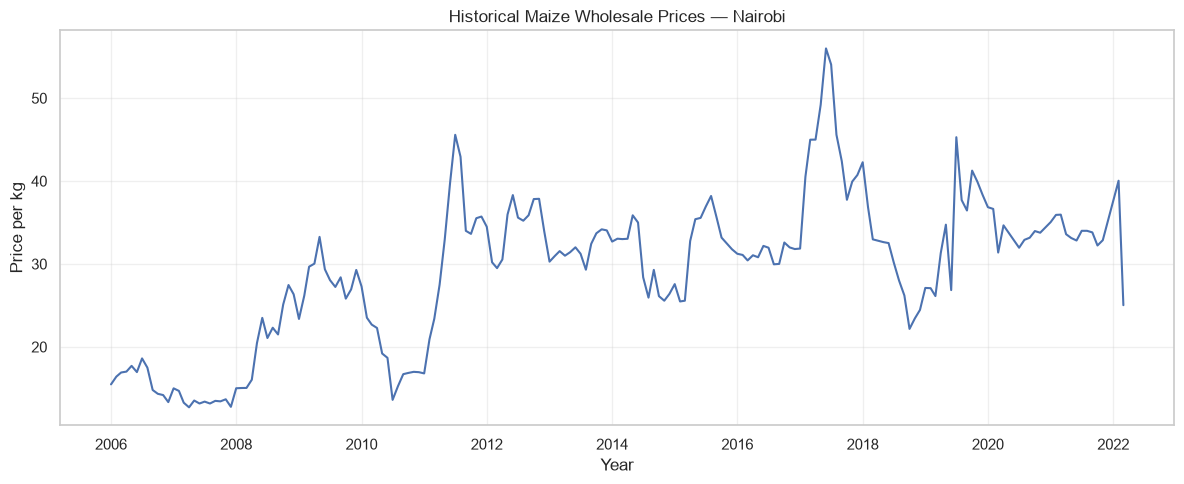

In [111]:
import matplotlib.pyplot as plt

# Plot the historical Nairobi maize wholesale price.
plt.figure(figsize=(12, 5))

plt.plot(
    maize_nairobi_wholesale["month_date"],
    maize_nairobi_wholesale["price_per_kg"]
)

plt.title("Historical Maize Wholesale Prices — Nairobi")
plt.xlabel("Year")
plt.ylabel("Price per kg")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

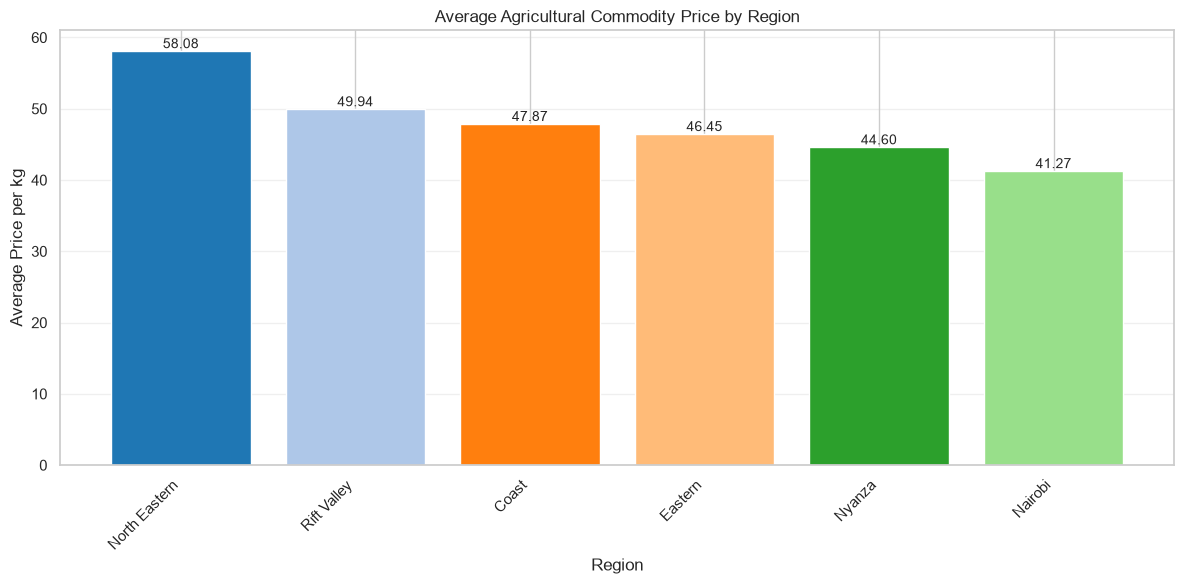

In [112]:
import matplotlib.pyplot as plt

# Calculate the average agricultural commodity price by region.
region_prices = (
    forecast_model_df
    .groupby("region")["price_per_kg"]
    .mean()
    .sort_values(ascending=False)
)

# Create a different color for each region.
colors = plt.cm.tab20(range(len(region_prices)))

# Create the bar chart.
plt.figure(figsize=(12, 6))

bars = plt.bar(
    region_prices.index,
    region_prices.values,
    color=colors
)

# Add values on top of the bars.
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Agricultural Commodity Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price per kg")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation

The average agricultural commodity price varies considerably across regions. North Eastern records the highest average price at 71.34 per kg, followed by Nairobi (56.54) and Rift Valley (56.29). Nyanza (48.62), Eastern (48.35), and Coast (47.87) have relatively similar average prices, while Central records the lowest average price at 37.71 per kg.

The difference between North Eastern and Central is substantial, suggesting that geographical location and market conditions may be associated with differences in agricultural commodity prices. However, these averages combine multiple commodities and should therefore be interpreted as overall regional price differences rather than evidence that location alone causes higher or lower prices.

#### Commodity trends by regions

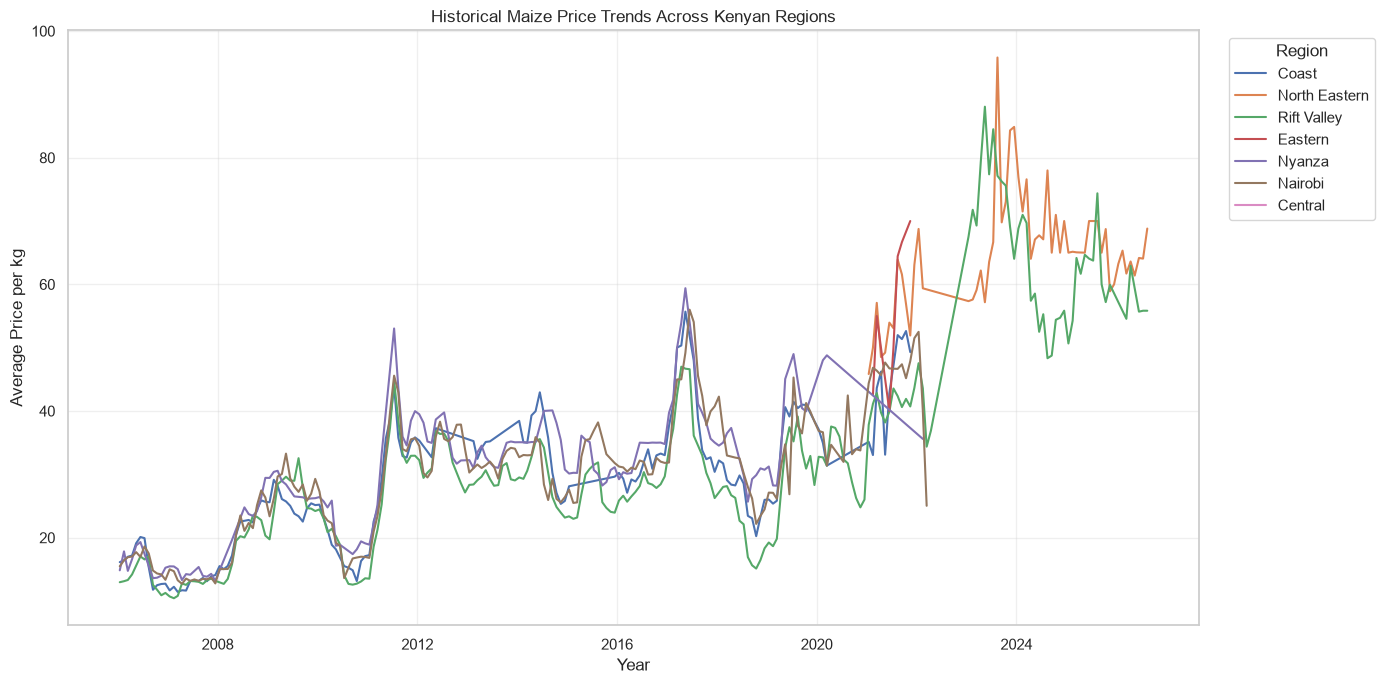

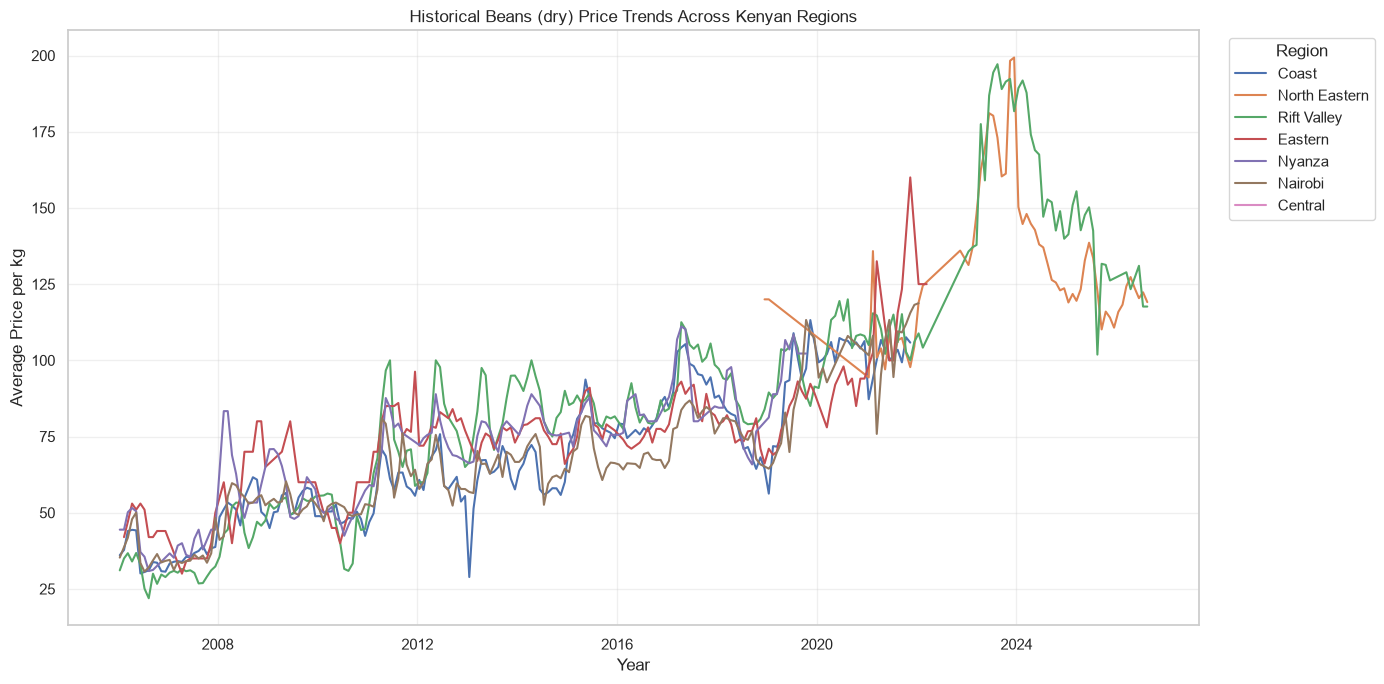

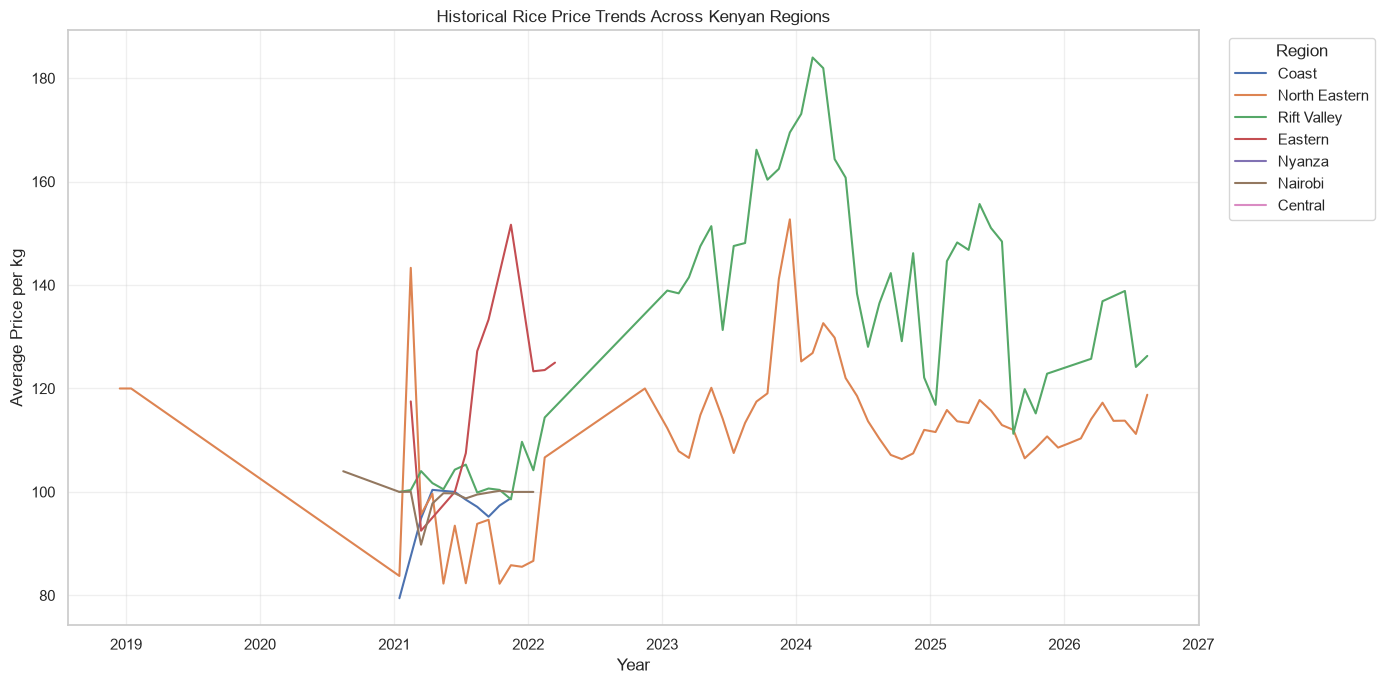

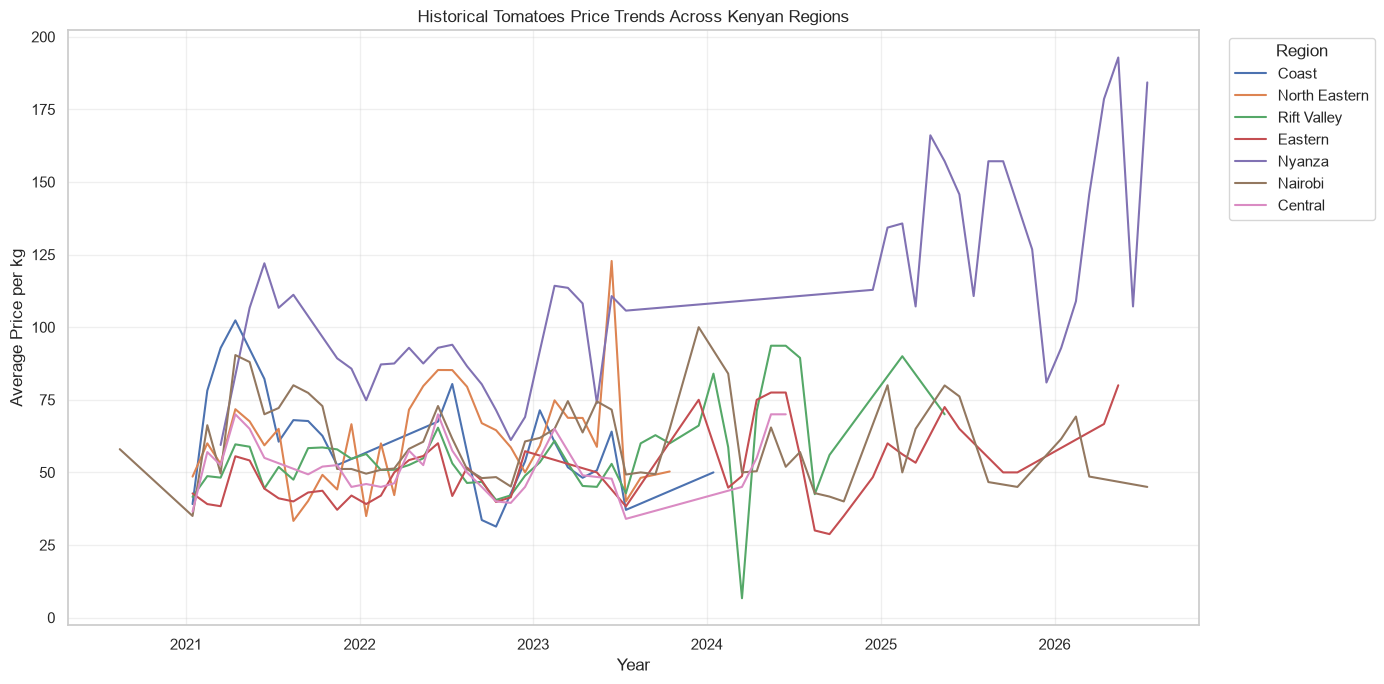

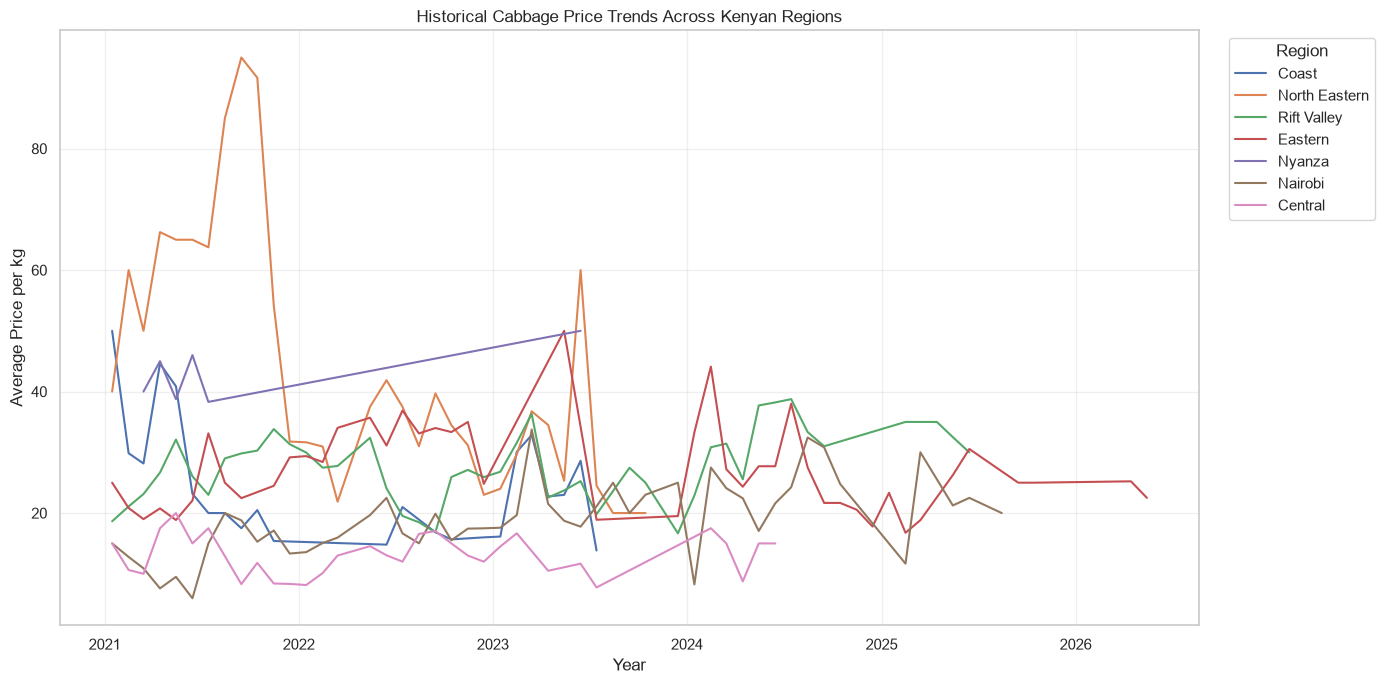

In [113]:
import matplotlib.pyplot as plt

# Major commodities to analyze
major_commodities = [
    "Maize",
    "Beans (dry)",
    "Rice",
    "Tomatoes",
    "Cabbage"
]

# Get the regions in the dataset
regions = agri_df["region"].dropna().unique()

# Loop through each major commodity
for commodity in major_commodities:

    # Filter for the selected commodity
    commodity_data = agri_df[
        agri_df["commodity"] == commodity
    ].copy()

    # Calculate average monthly price for each region
    regional_trends = (
        commodity_data
        .groupby(["date", "region"])["price_per_kg"]
        .mean()
        .reset_index()
    )

    # Create the graph
    plt.figure(figsize=(14, 7))

    # Plot each region
    for region in regions:

        region_data = regional_trends[
            regional_trends["region"] == region
        ]

        plt.plot(
            region_data["date"],
            region_data["price_per_kg"],
            label=region
        )

    plt.title(
        f"Historical {commodity} Price Trends Across Kenyan Regions"
    )
    plt.xlabel("Year")
    plt.ylabel("Average Price per kg")

    plt.legend(
        title="Region",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Rainfall lag vs. current maize price

In [131]:
# Create a dataframe for one-month lagged rainfall
# and current maize price

lag_analysis_df = (
    maize_ts.to_frame("price_per_kg")
    .join(
        maize_rainfall[["rainfall_mm"]],
        how="left"
    )
)

# Create the one-month rainfall lag
lag_analysis_df["rainfall_lag_1"] = (
    lag_analysis_df["rainfall_mm"].shift(1)
)

# Remove months where either price or lagged rainfall is missing
lag_analysis_df = lag_analysis_df[
    ["price_per_kg", "rainfall_lag_1"]
].dropna()

print("Observations:", len(lag_analysis_df))
print(lag_analysis_df.head())

Observations: 184
            price_per_kg  rainfall_lag_1
month_date                              
2006-02-01         16.41           17.97
2006-03-01         16.91           20.13
2006-04-01         17.02           88.87
2006-05-01         17.71          153.59
2006-06-01         16.96           93.38


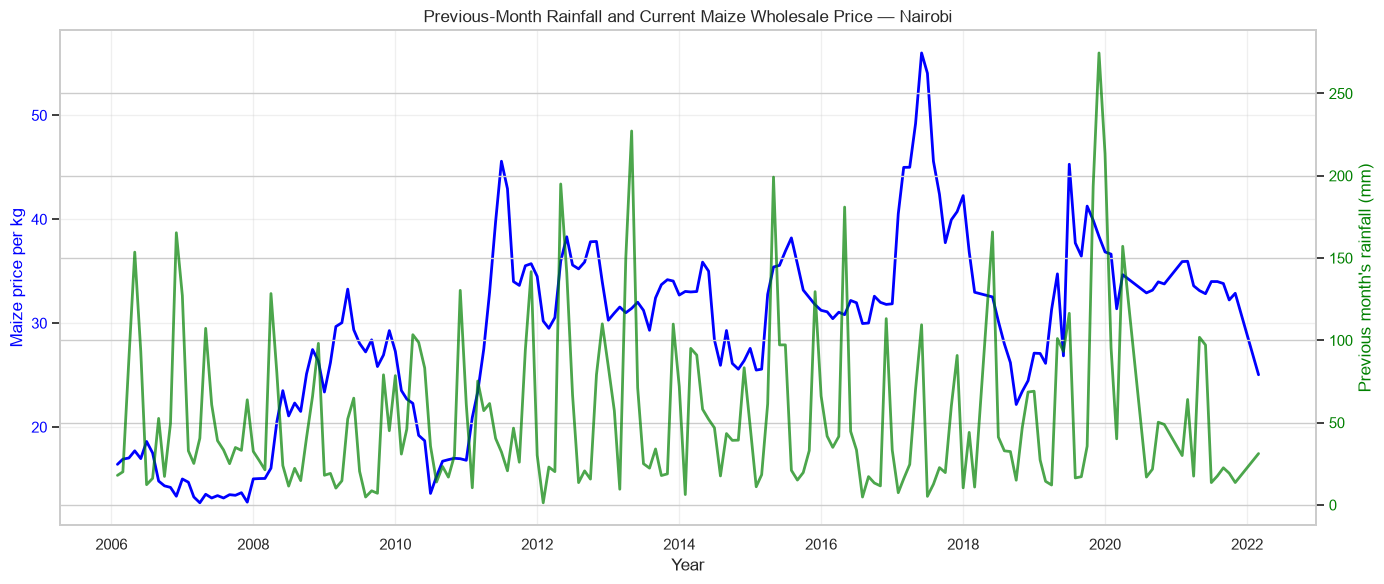

In [134]:
# Plot previous-month rainfall and current maize price over time

plot_data = lag_analysis_df.copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Current maize price
ax1.plot(
    plot_data.index,
    plot_data["price_per_kg"],
    color="blue",
    label="Current maize price",
    linewidth=2
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Maize price per kg", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Previous month's rainfall
ax2 = ax1.twinx()

ax2.plot(
    plot_data.index,
    plot_data["rainfall_lag_1"],
    color="green",
    label="Previous month's rainfall",
    linewidth=2,
    alpha=0.7
)

ax2.set_ylabel("Previous month's rainfall (mm)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title(
    "Previous-Month Rainfall and Current Maize Wholesale Price — Nairobi"
)

ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [139]:
# Create 6-month lagged rainfall and current maize price

lag6_df = (
    maize_ts.to_frame("price_per_kg")
    .join(
        maize_rainfall[["rainfall_mm"]],
        how="left"
    )
)

lag6_df["rainfall_lag_6"] = (
    lag6_df["rainfall_mm"].shift(6)
)

lag6_df = lag6_df[
    ["price_per_kg", "rainfall_lag_6"]
].dropna()

# Calculate the relationship
lag6_corr = lag6_df[
    ["rainfall_lag_6", "price_per_kg"]
].corr().iloc[0, 1]

print(f"6-month lag correlation: {lag6_corr:.3f}")

6-month lag correlation: -0.011


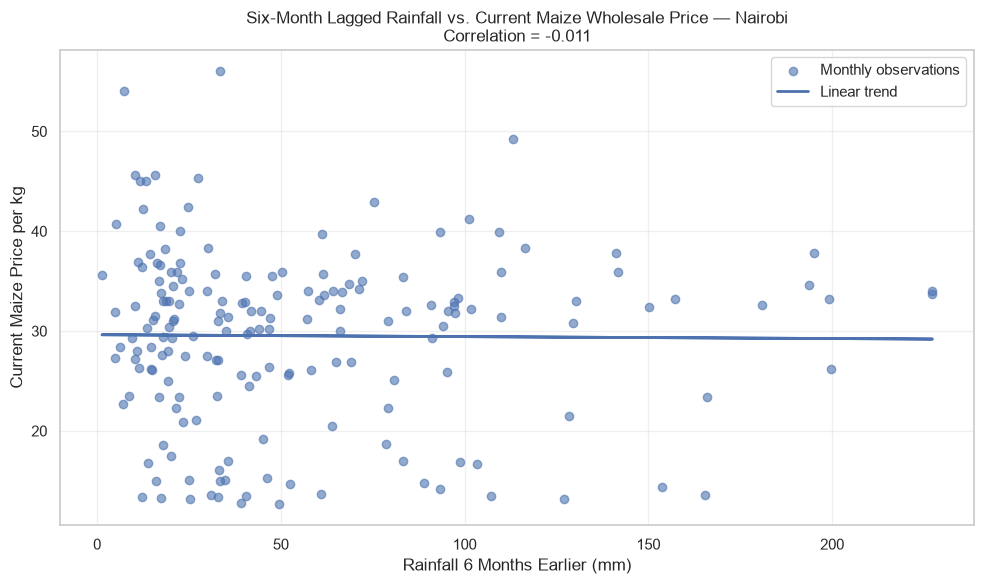

In [140]:
import matplotlib.pyplot as plt
import numpy as np

x = lag6_df["rainfall_lag_6"]
y = lag6_df["price_per_kg"]

# Fit a simple linear trend
slope, intercept = np.polyfit(x, y, 1)

trend = slope * x + intercept

plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.6,
    label="Monthly observations"
)

plt.plot(
    x,
    trend,
    linewidth=2,
    label="Linear trend"
)

plt.title(
    f"Six-Month Lagged Rainfall vs. Current Maize Wholesale Price — Nairobi\n"
    f"Correlation = {lag6_corr:.3f}"
)

plt.xlabel("Rainfall 6 Months Earlier (mm)")
plt.ylabel("Current Maize Price per kg")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

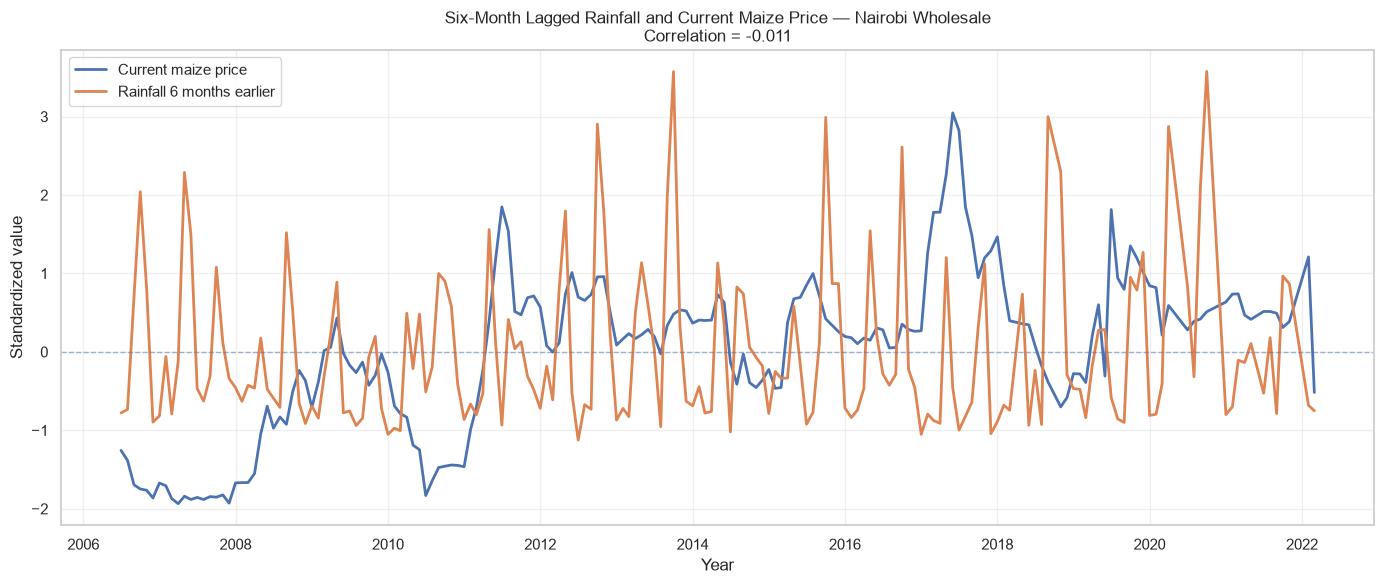

In [141]:
# Compare 6-month lagged rainfall with current maize price
# using standardized values so both variables share the same scale

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plot_df = lag6_df.copy()

# Standardize rainfall and price
scaler = StandardScaler()

plot_df[["price_scaled", "rainfall_scaled"]] = scaler.fit_transform(
    plot_df[["price_per_kg", "rainfall_lag_6"]]
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df.index,
    plot_df["price_scaled"],
    label="Current maize price",
    linewidth=2
)

plt.plot(
    plot_df.index,
    plot_df["rainfall_scaled"],
    label="Rainfall 6 months earlier",
    linewidth=2
)

plt.axhline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

plt.title(
    f"Six-Month Lagged Rainfall and Current Maize Price — Nairobi Wholesale\n"
    f"Correlation = {lag6_corr:.3f}"
)

plt.xlabel("Year")
plt.ylabel("Standardized value")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [145]:
# Create dataframe containing current maize price
# and rainfall from the previous 1–12 months

lag_analysis_df = (
    maize_ts.to_frame("price_per_kg")
    .join(
        maize_rainfall[["rainfall_mm"]],
        how="left"
    )
)

# Create rainfall lags from 1 to 12 months
for lag in range(1, 13):
    lag_analysis_df[f"rainfall_lag_{lag}"] = (
        lag_analysis_df["rainfall_mm"].shift(lag)
    )

# Check that all lag columns were created
print(lag_analysis_df.columns.tolist())

['price_per_kg', 'rainfall_mm', 'rainfall_lag_1', 'rainfall_lag_2', 'rainfall_lag_3', 'rainfall_lag_4', 'rainfall_lag_5', 'rainfall_lag_6', 'rainfall_lag_7', 'rainfall_lag_8', 'rainfall_lag_9', 'rainfall_lag_10', 'rainfall_lag_11', 'rainfall_lag_12']


In [146]:
# Calculate correlation between current maize price
# and rainfall from each previous month

lag_correlations = []

for lag in range(1, 13):

    correlation = lag_analysis_df[
        ["price_per_kg", f"rainfall_lag_{lag}"]
    ].corr().iloc[0, 1]

    lag_correlations.append({
        "lag": lag,
        "correlation": correlation
    })

lag_correlation_df = pd.DataFrame(lag_correlations)

print(lag_correlation_df)

    lag  correlation
0     1     0.083483
1     2     0.071452
2     3     0.050607
3     4    -0.010102
4     5    -0.036751
5     6    -0.010605
6     7    -0.007468
7     8    -0.029575
8     9    -0.047749
9    10    -0.038348
10   11    -0.034958
11   12     0.003437


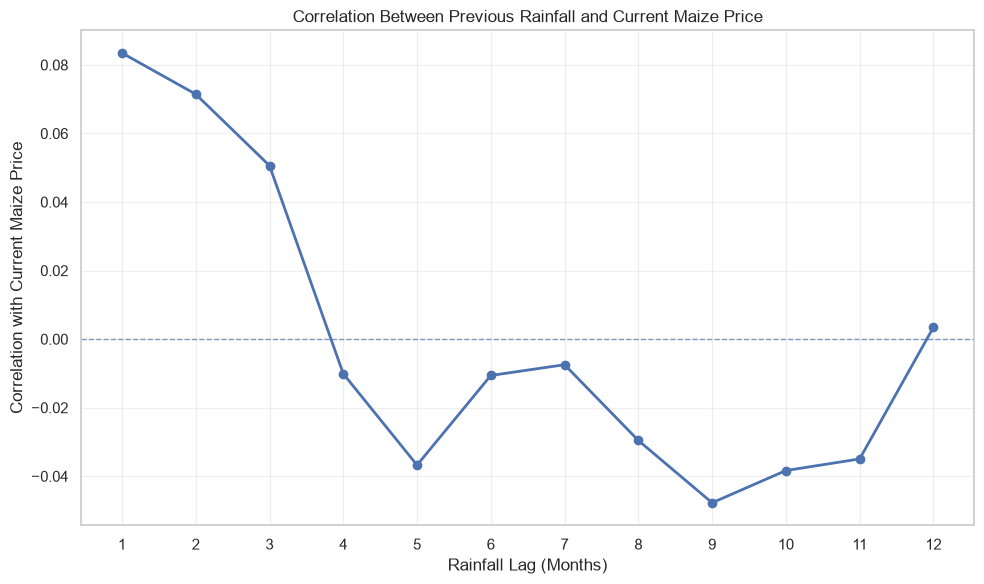

In [148]:
# Plot correlation between rainfall lag and current maize price

plt.figure(figsize=(10, 6))

plt.plot(
    lag_correlation_df["lag"],
    lag_correlation_df["correlation"],
    marker="o",
    linewidth=2
)

# Zero line separates positive and negative relationships
plt.axhline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.7
)

plt.title(
    "Correlation Between Previous Rainfall and Current Maize Price"
)

plt.xlabel("Rainfall Lag (Months)")
plt.ylabel("Correlation with Current Maize Price")

plt.xticks(range(1, 13))

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

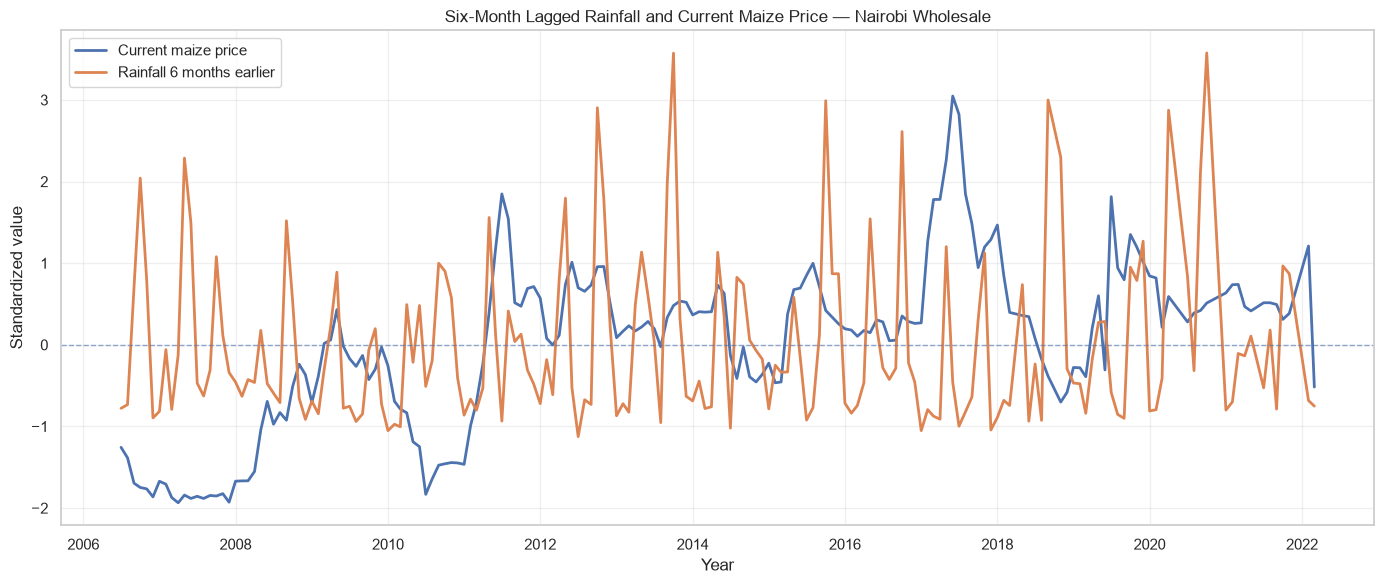

In [149]:
# Prepare data for the time-series comparison

plot_df = lag_analysis_df[
    ["price_per_kg", "rainfall_lag_6"]
].dropna().copy()

# Standardize both variables so they can be compared on the same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

plot_df[["price_scaled", "rainfall_scaled"]] = scaler.fit_transform(
    plot_df[["price_per_kg", "rainfall_lag_6"]]
)

# Plot both series
plt.figure(figsize=(14, 6))

plt.plot(
    plot_df.index,
    plot_df["price_scaled"],
    label="Current maize price",
    linewidth=2
)

plt.plot(
    plot_df.index,
    plot_df["rainfall_scaled"],
    label="Rainfall 6 months earlier",
    linewidth=2
)

# Reference line
plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

plt.title(
    "Six-Month Lagged Rainfall and Current Maize Price — Nairobi Wholesale"
)

plt.xlabel("Year")
plt.ylabel("Standardized value")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Data Report
https://docs.google.com/document/d/1OrkqUvFjccdfDCuhB9kmLPUYLBwqsn51AliJZqT7y2o/edit?tab=t.0#heading=h.erbznhxlhgv

In [150]:
import joblib

# Save the fitted SARIMAX model
joblib.dump(
    sarimax_result,
    "agripulse_sarimax_maize_nairobi_lag6.pkl"
)

print("SARIMAX model saved successfully.")

SARIMAX model saved successfully.


In [151]:
model_info = {
    "project": "Agripulse Kenya",
    "commodity": "Maize",
    "market": "Nairobi",
    "price_type": "Wholesale",
    "model": "SARIMAX",
    "order": (2, 1, 0),
    "seasonal_order": (0, 0, 1, 12),
    "exogenous_variable": "rainfall_lag_6",
    "target": "price_per_kg",
    "MAE": 3.67,
    "RMSE": 4.78,
    "MAPE": 12.05
}

joblib.dump(
    model_info,
    "agripulse_sarimax_maize_nairobi_lag6_info.pkl"
)

print("Model information saved successfully.")

Model information saved successfully.


In [152]:
import os

print(os.path.exists("agripulse_sarimax_maize_nairobi_lag6.pkl"))
print(os.path.exists("agripulse_sarimax_maize_nairobi_lag6_info.pkl"))

True
True
